In [1]:
%pip install "chronos-forecasting>=2.0" swig "gymnasium[box2d]" stable-baselines3 pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
from chronos import Chronos2Pipeline

c:\Users\Fatjon Tushe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2",)

# Load historical target values and past values of covariates
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")
print(context_df.head())

# (Optional) Load future values of covariates
future_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet").drop(columns="target")
print(future_df.head())

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)
print(pred_df)


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 2000.81it/s]


   id           timestamp     target  Ampirion Load Forecast  PV+Wind Forecast
0  DE 2012-01-09 00:00:00  34.970001                16382.00       3569.527588
1  DE 2012-01-09 01:00:00  33.430000                15410.50       3315.274902
2  DE 2012-01-09 02:00:00  32.740002                15595.00       3107.307617
3  DE 2012-01-09 03:00:00  32.459999                16521.00       2944.620117
4  DE 2012-01-09 04:00:00  32.500000                17700.75       2897.149902
   id           timestamp  Ampirion Load Forecast  PV+Wind Forecast
0  DE 2017-12-12 00:00:00                20483.00      22284.005859
1  DE 2017-12-12 01:00:00                19849.75      22878.673828
2  DE 2017-12-12 02:00:00                19638.25      23632.283203
3  DE 2017-12-12 03:00:00                19895.25      24635.945312
4  DE 2017-12-12 04:00:00                20338.00      25584.935547
    id           timestamp target_name  predictions        0.1        0.5  \
0   DE 2017-12-12 00:00:00      target   

In [4]:
# Collect data from the enviroment via Random Sampling
env = gym.make("LunarLanderContinuous-v3")
obs, _ = env.reset(seed=42)

records = []
for t in range(1000):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)

    # combined vector: [s_t (8 dims), a_t (2 dims)]
    row = np.concatenate([obs, action])
    records.append(row)

    obs = next_obs
    if terminated or truncated:
        obs, _ = env.reset()

env.close()

feature_names = [
    "pos_x", "pos_y", "vel_x", "vel_y",
    "angle", "ang_vel", "leg_L", "leg_R",
    "act_main", "act_side"
]
df = pd.DataFrame(records, columns=feature_names)

print(df.head())

      pos_x     pos_y     vel_x     vel_y     angle   ang_vel  leg_L  leg_R  \
0  0.002297  1.418131  0.232647  0.320467 -0.002655 -0.052698    0.0    0.0   
1  0.004434  1.425514  0.215458  0.328152 -0.004432 -0.035541    0.0    0.0   
2  0.006616  1.432303  0.221197  0.301692 -0.007357 -0.058512    0.0    0.0   
3  0.008743  1.438496  0.214274  0.275239 -0.008891 -0.030677    0.0    0.0   
4  0.010942  1.445299  0.219609  0.302388 -0.008674  0.004332    0.0    0.0   

   act_main  act_side  
0  0.355985 -0.559428  
1 -0.673939  0.545402  
2 -0.035547 -0.655302  
3  0.559787 -0.763467  
4  0.425355  0.769039  


In [5]:
env = gym.make("LunarLanderContinuous-v3")
obs, _ = env.reset(seed=42)

records = []
episode_id = 0
step_in_episode = 0

for t in range(1000):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    
    # Calculate state deltas (\Delta s_t = s_{t+1} - s_t) for Chronos target outputs
    delta_s = next_obs - obs 
    
    # Store: [item_id, timestamp, s_t (8), a_t (2), \Delta s_t (8)]
    row = [
        episode_id,
        step_in_episode,
        *obs,       # pos_x, pos_y, vel_x, vel_y, angle, ang_vel, leg_L, leg_R
        *action,    # act_main, act_side
        *delta_s    # target deltas for state updates
    ]
    records.append(row)
    
    obs = next_obs
    step_in_episode += 1
    
    if terminated or truncated:
        obs, _ = env.reset()
        episode_id += 1
        step_in_episode = 0

env.close()

# Construct Master DataFrame
columns = [
    "id", "timestamp",
    "pos_x", "pos_y", "vel_x", "vel_y", "angle", "ang_vel", "leg_L", "leg_R",
    "act_main", "act_side",
    "d_pos_x", "d_pos_y", "d_vel_x", "d_vel_y", "d_angle", "d_ang_vel", "d_leg_L", "d_leg_R" # targets
]

full_df = pd.DataFrame(records, columns=columns)

# Convert integer steps to pandas datetime (required by standard Chronos pipelines)
full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], unit='s')

# Slice into context_df and futures_df
# Context Length K and Forecast Horizon H
K = 32 
H = 24

# Filter for episodes that are long enough (len >= K + H)
valid_episodes = full_df.groupby('id').filter(lambda x: len(x) >= (K + H))
target_episode = valid_episodes['id'].iloc[0]

single_episode_df = full_df[full_df['id'] == target_episode].reset_index(drop=True)

context_df = single_episode_df.iloc[:K].copy()
context_df = context_df[["id", "timestamp","act_main", "act_side", "d_pos_x", "d_pos_y", "d_vel_x", "d_vel_y", "d_angle", "d_ang_vel", "d_leg_L", "d_leg_R"]]

# futures_df gets ONLY id, timestamp, and actions for steps K..K+H
action_covariates = ["id", "timestamp", "act_main", "act_side"]
futures_df = single_episode_df.iloc[K:K+H][action_covariates].copy()

print("--- CONTEXT DF ---")
print(context_df.head())

print("\n--- FUTURES DF (Covariates only) ---")
print(futures_df.head())

--- CONTEXT DF ---
   id           timestamp  act_main  act_side   d_pos_x   d_pos_y   d_vel_x  \
0   0 1970-01-01 00:00:00  0.588110 -0.743142  0.002101  0.007512 -0.021134   
1   0 1970-01-01 00:00:01 -0.645988 -0.177245  0.002101  0.006913  0.000005   
2   0 1970-01-01 00:00:02 -0.745863  0.072085  0.002101  0.006313  0.000004   
3   0 1970-01-01 00:00:03 -0.759801  0.123787  0.002101  0.005713  0.000004   
4   0 1970-01-01 00:00:04 -0.763584 -0.597350  0.002047  0.005118 -0.006789   

    d_vel_y   d_angle  d_ang_vel  d_leg_L  d_leg_R  
0  0.013408 -0.001424   0.024225      0.0      0.0  
1 -0.026637 -0.001423   0.000018      0.0      0.0  
2 -0.026667 -0.001422   0.000006      0.0      0.0  
3 -0.026668 -0.001422   0.000004      0.0      0.0  
4 -0.026452 -0.000059   0.027263      0.0      0.0  

--- FUTURES DF (Covariates only) ---
    id           timestamp  act_main  act_side
32   0 1970-01-01 00:00:32  0.425340 -0.507342
33   0 1970-01-01 00:00:33  0.495087  0.676386
34   0 19

In [6]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=futures_df,
    prediction_length=H,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target=["d_pos_x", "d_pos_y", "d_vel_x", "d_vel_y", "d_angle", "d_ang_vel", "d_leg_L", "d_leg_R"],  # Column(s) with time series values to predict
)
print(pred_df.head())

   id           timestamp target_name  predictions       0.1       0.5  \
0   0 1970-01-01 00:00:32     d_pos_x     0.002032  0.001948  0.002032   
1   0 1970-01-01 00:00:33     d_pos_x     0.002038  0.001918  0.002038   
2   0 1970-01-01 00:00:34     d_pos_x     0.002042  0.001898  0.002042   
3   0 1970-01-01 00:00:35     d_pos_x     0.002047  0.001884  0.002047   
4   0 1970-01-01 00:00:36     d_pos_x     0.002065  0.001866  0.002065   

        0.9  
0  0.002131  
1  0.002167  
2  0.002196  
3  0.002235  
4  0.002284  


In [7]:
import pandas as pd
import numpy as np

# --- Parameters & Column Definitions ---
K = 32  # Fixed Context Window length
H = 24  # Prediction Horizon
num_horizons = 3  # Number of autoregressive steps (Total forecast = num_horizons * H)

target_cols = [
    "d_pos_x", "d_pos_y", "d_vel_x", "d_vel_y", 
    "d_angle", "d_ang_vel", "d_leg_L", "d_leg_R"
]
state_cols = [
    "pos_x", "pos_y", "vel_x", "vel_y", 
    "angle", "ang_vel", "leg_L", "leg_R"
]
action_cols = ["act_main", "act_side"]

current_state = single_episode_df[state_cols].iloc[K - 1].values.copy()

# Ensure target_episode data contains total needed steps: K + (num_horizons * H)
total_future_actions_df = single_episode_df.iloc[K: K + (num_horizons * H)].reset_index(drop=True)

# List to accumulate all autoregressive predictions across iterations
all_predictions_df = []

# Make copies to manipulate dynamically
curr_context_df = context_df[["id", "timestamp"] + action_cols + target_cols].copy()

for step in range(num_horizons):
    # Get the planned future actions for the current horizon H
    start_idx = step * H
    end_idx = start_idx + H
    
    curr_futures_df = total_future_actions_df.iloc[start_idx:end_idx][["id", "timestamp"] + action_cols].copy()
    

    pred_df = pipeline.predict_df(
        curr_context_df,
        future_df=curr_futures_df,
        prediction_length=H,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id",
        timestamp_column="timestamp",
        target=target_cols,
    )

    print(pred_df.head())
    
    target_id_col = "target_name" if "target_name" in pred_df.columns else "target"
    
    # Detect the median forecast column (quantile level 0.5 or 'predictions')
    value_col = 0.5 if 0.5 in pred_df.columns else "predictions"

    # Pivot long format -> wide format (Columns become target_cols)
    median_preds = pred_df.pivot(
        index="timestamp", 
        columns=target_id_col, 
        values=value_col
    )[target_cols].reset_index()
    print(median_preds)

    # Reconstruct predicted absolute states (s_{t+1} = s_t + \Delta s_t)
    # last_known_state = curr_context_df[state_cols].iloc[-1].values
    
    predicted_deltas = median_preds[target_cols].values
    predicted_states = np.zeros_like(predicted_deltas)
    
    # current_state = last_known_state
    for i in range(H):
        current_state = current_state + predicted_deltas[i]
        predicted_states[i] = current_state.copy()

    # Build new rows to append back to context_df
    new_context_rows = curr_futures_df.copy()
    for idx, col in enumerate(target_cols):
        new_context_rows[col] = predicted_deltas[:, idx]
    
    # Add predicted states and deltas
    for idx, col in enumerate(state_cols):
        new_context_rows[col] = predicted_states[:, idx]
        
    for idx, col in enumerate(target_cols):
        new_context_rows[col] = predicted_deltas[:, idx]
        
    # Reorder columns to match original context_df schema
    new_context_rows = new_context_rows[curr_context_df.columns]
    
    # Keep track of generated forecasts
    all_predictions_df.append(new_context_rows)
    
    # append new predictions and maintain fixed sliding window K
    curr_context_df = pd.concat([curr_context_df, new_context_rows], ignore_index=True)
    curr_context_df = curr_context_df.iloc[-K:].reset_index(drop=True)

# Combine all autoregressive predictions into a single DataFrame
final_forecast_df = pd.concat(all_predictions_df, ignore_index=True)

print("--- FULL AUTOREGRESSIVE FORECAST (Length: {}) ---".format(len(final_forecast_df)))
print(final_forecast_df.head(10))

   id           timestamp target_name  predictions       0.1       0.5  \
0   0 1970-01-01 00:00:32     d_pos_x     0.002032  0.001948  0.002032   
1   0 1970-01-01 00:00:33     d_pos_x     0.002038  0.001918  0.002038   
2   0 1970-01-01 00:00:34     d_pos_x     0.002042  0.001898  0.002042   
3   0 1970-01-01 00:00:35     d_pos_x     0.002047  0.001884  0.002047   
4   0 1970-01-01 00:00:36     d_pos_x     0.002065  0.001866  0.002065   

        0.9  
0  0.002131  
1  0.002167  
2  0.002196  
3  0.002235  
4  0.002284  
target_name           timestamp   d_pos_x   d_pos_y   d_vel_x   d_vel_y  \
0           1970-01-01 00:00:32  0.002032 -0.000824 -0.003041  0.002189   
1           1970-01-01 00:00:33  0.002038 -0.000839  0.001182  0.004720   
2           1970-01-01 00:00:34  0.002042 -0.000852  0.001025 -0.010018   
3           1970-01-01 00:00:35  0.002047 -0.000935 -0.007128  0.000610   
4           1970-01-01 00:00:36  0.002065 -0.000824  0.002047  0.015476   
5           1970-01-0

In [8]:
num_forecast_steps = len(final_forecast_df) # num_horizons * H

# Ground truth starts immediately after context window K
ground_truth_df = single_episode_df.iloc[K : K + num_forecast_steps].reset_index(drop=True)

# absolute state right at the end of context window K (step K-1)
anchor_state = single_episode_df[state_cols].iloc[K - 1].to_numpy()

# Compute Target Delta MSE
y_true_deltas = ground_truth_df[target_cols].values
y_pred_deltas = final_forecast_df[target_cols].values

delta_mse_per_channel = np.mean((y_true_deltas - y_pred_deltas) ** 2, axis=0)
total_delta_mse = np.mean(delta_mse_per_channel)

# Compute Reconstructed Absolute State MSE
y_pred_states = anchor_state + np.cumsum(y_pred_deltas, axis=0)

y_true_states = ground_truth_df[state_cols].to_numpy()

state_mse_per_channel = np.mean((y_true_states - y_pred_states) ** 2, axis=0)
total_state_mse = np.mean(state_mse_per_channel)

print("==================================================")
print(f"  EVALUATION RESULTS ({num_forecast_steps} Steps Autoregressive)")
print("==================================================")
print(f"Overall Delta MSE  (Δs): {total_delta_mse:.6f}")
print(f"Overall State MSE  (s) : {total_state_mse:.6f}\n")

# Per-channel Breakdown Table
mse_summary = pd.DataFrame({
    "State Variable": state_cols,
    "Delta Column": target_cols,
    "Delta MSE (Δs)": delta_mse_per_channel,
    "State MSE (s)": state_mse_per_channel
})

print(mse_summary.to_string(index=False))

  EVALUATION RESULTS (72 Steps Autoregressive)
Overall Delta MSE  (Δs): 0.000040
Overall State MSE  (s) : 0.008459

State Variable Delta Column  Delta MSE (Δs)  State MSE (s)
         pos_x      d_pos_x    1.589466e-07   1.842160e-04
         pos_y      d_pos_y    7.330679e-05   2.851984e-02
         vel_x      d_vel_x    5.741559e-05   2.108478e-03
         vel_y      d_vel_y    5.874096e-05   8.282061e-03
         angle      d_angle    3.437235e-05   2.325681e-02
       ang_vel    d_ang_vel    9.607562e-05   5.322976e-03
         leg_L      d_leg_L    8.249794e-17   2.929789e-14
         leg_R      d_leg_R    8.249794e-17   2.929789e-14


# Custom World Models

In [9]:
from gymnasium import spaces
import collections

class LunarLanderTSFMEnv(gym.Env):
    """
    Custom Gymnasium Environment that uses Chronos 2.0 as a World Model
    to forecast environment transitions z-shot / in-context.
    """
    metadata = {"render_modes": []}

    def __init__(self, context_length=16,
                 model_name="amazon/chronos-2",
                 device="cuda",
                 grace_period_steps=10,
                 use_residual_updates=True,
                 ):
        super().__init__()

        self.context_length = context_length
        self.device = device
        self.grace_period_steps = grace_period_steps
        self.use_residual_updates = use_residual_updates

        # Physical bounds for state clipping
        self.low_bounds = np.array(
            [-2.5, -2.5, -10.0, -10.0, -2 * np.pi, -10.0, 0.0, 0.0], dtype=np.float32
        )
        self.high_bounds = np.array(
            [2.5, 2.5, 10.0, 10.0, 2 * np.pi, 10.0, 1.0, 1.0], dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=self.low_bounds, high=self.high_bounds, dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(2,), dtype=np.float32
        )

        # Load Pretrained Chronos 2.0 Pipeline from HuggingFace
        print(f"Loading TSFM World Model ({model_name})")
        self.pipeline = Chronos2Pipeline.from_pretrained(
            model_name,
            device_map=self.device,
            dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        )

        # History buffers for states and actions
        self.obs_history = collections.deque(maxlen=self.context_length)
        self.action_history = collections.deque(maxlen=self.context_length)

        # Column names for pandas DataFrames for Chronos.predict_df
        self.target_column_names = [
            "d_pos_x", "d_pos_y", "d_vel_x", "d_vel_y", 
            "d_angle", "d_ang_vel", "d_leg_L", "d_leg_R"
        ]
        self.action_column_names = ["act_main", "act_side"]
        self.all_feature_column_names = self.target_column_names + self.action_column_names

        self.current_step = 0
        self.max_steps = 500

        # Internal real environment for warm-up
        self._real_env = gym.make("LunarLanderContinuous-v3")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0

        # Clear history buffers
        self.obs_history.clear()
        self.action_history.clear()

        # Reset the internal real environment
        current_real_obs, _ = self._real_env.reset(seed=seed)

        # Warm-up the context buffer with actual steps from the real environment
        for _ in range(self.context_length - 1):
            self.obs_history.append(current_real_obs.copy())
            action = self._real_env.action_space.sample() # Random actions for warm-up
            self.action_history.append(action.copy())
            current_real_obs, _, _, _, _ = self._real_env.step(action)

        # Append the last observation from the warm-up, and a zero action as the "current" action
        # before the first step() call where a real action is passed.
        self.obs_history.append(current_real_obs.copy())
        # The action at the *end* of context is the one that led to the *current* state.
        # If we just reset, no action has been taken yet for the current_real_obs to be a result of.
        # We set it to zeros, as the first step() call will provide a real action.
        self.action_history.append(np.zeros(2, dtype=np.float32))

        # Initialize previous shaping score for differential reward computation based on the *current* observation
        self.prev_shaping = self._get_shaping(current_real_obs)

        return current_real_obs, {}

    def step(self, action):
        self.current_step += 1

        # previous observation for residual update if needed
        prev_obs = self.obs_history[-1].copy()

        # Compute Historical Deltas for Context DF
        # context_length = K. We calculate K - 1 historical deltas (\Delta s_i = s_{i+1} - s_i)
        deltas = []
        for i in range(self.context_length - 1):
            d_s = self.obs_history[i + 1] - self.obs_history[i]
            deltas.append(d_s)

        # For the last context step (K-1), the next state doesn't exist yet,
        # so we pad the delta target column with zeros.
        deltas.append(np.zeros(8, dtype=np.float32))

        # Construct context_df (Target Deltas + Past Actions)
        context_data = []
        for i in range(self.context_length):
            # Combined vector: [\Delta s_t (8 dims), a_t (2 dims)]
            row = np.concatenate([deltas[i], self.action_history[i]])
            context_data.append(row)

        context_df = pd.DataFrame(context_data, columns=self.all_feature_column_names)
        context_df['id'] = 0
        context_df['timestamp'] = pd.to_datetime(np.arange(self.context_length), unit='s')

        # Current Action Covariate
        future_data = pd.DataFrame([action], columns=self.action_column_names)
        future_df = future_data.copy()
        future_df['id'] = 0
        future_df['timestamp'] = pd.to_datetime([self.context_length], unit='s')

        # Predict State Delta 
        with torch.no_grad():
            pred_df = self.pipeline.predict_df(
                context_df,
                future_df=future_df,
                prediction_length=1,
                id_column="id",
                timestamp_column="timestamp",
                target=self.target_column_names,
            )

            target_id_col = "target_name" if "target_name" in pred_df.columns else "target"
            value_col = 0.5 if 0.5 in pred_df.columns else "predictions"

            # Pivot long format to wide format matching target_column_names order
            pivoted_df = pred_df.pivot(
                index="timestamp", 
                columns=target_id_col, 
                values=value_col
            )
            raw_pred_delta = pivoted_df[self.target_column_names].values[0]

        # Handle NaNs and Reconstruct Absolute Next Observation
        if np.isnan(raw_pred_delta).any():
            print(f"Warning: Chronos predicted NaNs at step {self.current_step}. Replacing delta with 0.0.")
            raw_pred_delta = np.nan_to_num(raw_pred_delta, nan=0.0)

        # Apply predicted delta to last known absolute observation
        if self.use_residual_updates:
            next_obs_pred = prev_obs + raw_pred_delta
        else:
            next_obs_pred = raw_pred_delta

        # Clip predictions to physical environment bounds
        next_obs_pred = np.clip(next_obs_pred, self.low_bounds, self.high_bounds)

        # Termination Conditions
        x_limit = 1.5 if self.current_step <= self.grace_period_steps else 1.2
        tilt_limit = 0.8 if self.current_step <= self.grace_period_steps else 0.6

        is_out_of_bounds_x = abs(next_obs_pred[0]) > x_limit
        is_tilted = abs(next_obs_pred[4]) > tilt_limit
        is_crashed = next_obs_pred[1] <= 0.0 and np.sqrt(next_obs_pred[2]**2 + next_obs_pred[3]**2) > 1.5

        terminated = bool(is_out_of_bounds_x or is_tilted or is_crashed)
        truncated = self.current_step >= self.max_steps

        # Compute Reward & Update History Buffers
        reward = self._compute_reward(next_obs_pred, action, terminated=terminated)

        self.obs_history.append(next_obs_pred.copy())
        self.action_history.append(action.copy())

        return next_obs_pred, reward, terminated, truncated, {}

    def _get_shaping(self, obs):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      shaping = (
          - 100.0 * np.sqrt(x**2 + y**2)
          - 100.0 * np.sqrt(vx**2 + vy**2)
          - 100.0 * abs(theta)
          + 10.0 * leg1
          + 10.0 * leg2
      )
      return shaping

    def _compute_reward(self, obs, action, terminated=False):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      main_engine, side_engine = action

      # 1. Differential shaping reward (shaping_t - shaping_{t-1})
      current_shaping = self._get_shaping(obs)
      reward = current_shaping - self.prev_shaping
      self.prev_shaping = current_shaping

      # 2. Fuel consumption penalty
      if main_engine > 0.0:
          reward -= main_engine * 0.30
      if abs(side_engine) > 0.5:
          reward -= abs(side_engine) * 0.03

      # 3. Terminal Outcome
      if terminated:
          # is_crashed logic should align with the terminated condition in step
          is_crashed = abs(x) > 1.2 or abs(theta) > 0.6 or np.sqrt(vx**2 + vy**2) > 1.5
          if is_crashed:
              reward -= 100.0
          else:
              reward += 100.0

      return float(reward)

In [10]:
class LunarLanderPersistenceEnv(gym.Env):
    """
    Gymnasium Environment that uses a simple persistence model as a World Model
    to forecast environment transitions.
    """
    metadata = {"render_modes": []}

    def __init__(self, max_steps=500, grace_period_steps=10):
        super().__init__()
        # Physical bounds for state clipping
        self.low_bounds = np.array(
            [-2.5, -2.5, -10.0, -10.0, -2 * np.pi, -10.0, 0.0, 0.0], dtype=np.float32
        )
        self.high_bounds = np.array(
            [2.5, 2.5, 10.0, 10.0, 2 * np.pi, 10.0, 1.0, 1.0], dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=self.low_bounds, high=self.high_bounds, dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(2,), dtype=np.float32
        )
        self.max_steps = max_steps
        self.current_step = 0
        self.current_obs = None
        self.grace_period_steps = grace_period_steps

        # Use a real environment instance to get initial states for resets and define space bounds
        self._real_env = gym.make("LunarLanderContinuous-v3")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        initial_obs, info = self._real_env.reset(seed=seed, options=options)
        self.current_obs = initial_obs

        # Initialize previous shaping score for differential reward computation
        self.prev_shaping = self._get_shaping(initial_obs)

        return self.current_obs, info

    def step(self, action):
        self.current_step += 1
        # Persistence model: next state is assumed to be the current state
        next_obs_pred = self.current_obs.copy()

        x_limit = 1.5 if self.current_step <= self.grace_period_steps else 1.2
        tilt_limit = 0.8 if self.current_step <= self.grace_period_steps else 0.6

        is_out_of_bounds_x = abs(next_obs_pred[0]) > x_limit
        is_tilted = abs(next_obs_pred[4]) > tilt_limit
        is_crashed = next_obs_pred[1] <= 0.0 and np.sqrt(next_obs_pred[2]**2 + next_obs_pred[3]**2) > 1.5

        terminated = bool(is_out_of_bounds_x or is_tilted or is_crashed)
        truncated = self.current_step >= self.max_steps

        reward = self._compute_reward(next_obs_pred, action, terminated=terminated)

        self.current_obs = next_obs_pred # Update current observation for the next step
        return next_obs_pred, reward, terminated, truncated, {}

    def _get_shaping(self, obs):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      shaping = (
          - 100.0 * np.sqrt(x**2 + y**2)
          - 100.0 * np.sqrt(vx**2 + vy**2)
          - 100.0 * abs(theta)
          + 10.0 * leg1
          + 10.0 * leg2
      )
      return shaping

    def _compute_reward(self, obs, action, terminated=False):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      main_engine, side_engine = action

      # 1. Differential shaping reward (shaping_t - shaping_{t-1})
      current_shaping = self._get_shaping(obs)
      reward = current_shaping - self.prev_shaping
      self.prev_shaping = current_shaping

      # 2. Fuel consumption penalty
      if main_engine > 0.0:
          reward -= main_engine * 0.30
      if abs(side_engine) > 0.5:
          reward -= abs(side_engine) * 0.03

      # 3. Terminal Outcome
      if terminated:
          # is_crashed logic should align with the terminated condition in step
          is_crashed = abs(x) > 1.2 or abs(theta) > 0.6 or np.sqrt(vx**2 + vy**2) > 1.5
          if is_crashed:
              reward -= 100.0
          else:
              reward += 100.0

      return float(reward)

    def close(self):
        self._real_env.close()

print("LunarLanderPersistenceEnv class defined.")

LunarLanderPersistenceEnv class defined.


In [11]:
import torch
import torch.nn as nn

class MLPDynamicsModel(nn.Module):
    def __init__(self, state_dim=8, action_dim=2, hidden_dim=64):
        super(MLPDynamicsModel, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, state_dim)
        self.relu = nn.ReLU()

    def forward(self, state, action):
        # Concatenate state and action
        x = torch.cat([state, action], dim=-1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        next_state_pred = self.fc3(x)
        return next_state_pred

print("MLPDynamicsModel class defined.")

MLPDynamicsModel class defined.


In [12]:
class LunarLanderMLPEnv(gym.Env):
    """
    Gymnasium Environment that uses an MLP dynamics model as a World Model
    to forecast environment transitions.
    """
    metadata = {"render_modes": []}

    def __init__(self, mlp_model_instance, max_steps=500, grace_period_steps=10):
        super().__init__()
        self.mlp_model = mlp_model_instance
        # Physical bounds for state clipping
        self.low_bounds = np.array(
            [-2.5, -2.5, -10.0, -10.0, -2 * np.pi, -10.0, 0.0, 0.0], dtype=np.float32
        )
        self.high_bounds = np.array(
            [2.5, 2.5, 10.0, 10.0, 2 * np.pi, 10.0, 1.0, 1.0], dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=self.low_bounds, high=self.high_bounds, dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(2,), dtype=np.float32
        )
        self.max_steps = max_steps
        self.current_step = 0
        self.current_obs = None
        self.grace_period_steps = grace_period_steps
        # Use a real environment instance to get initial states for resets and define space bounds
        self._real_env = gym.make("LunarLanderContinuous-v3")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        initial_obs, info = self._real_env.reset(seed=seed, options=options)
        self.current_obs = initial_obs

        # Initialize previous shaping score for differential reward computation
        self.prev_shaping = self._get_shaping(initial_obs)

        return self.current_obs, info

    def step(self, action):
        self.current_step += 1
        # MLP model: predict next state
        with torch.no_grad():
            state_tensor = torch.from_numpy(self.current_obs).float().unsqueeze(0) # Add batch dim
            action_tensor = torch.from_numpy(action).float().unsqueeze(0) # Add batch dim
            next_obs_pred_tensor = self.mlp_model(state_tensor, action_tensor)
            next_obs_pred = next_obs_pred_tensor.squeeze(0).cpu().numpy() # Remove batch dim

        x_limit = 1.5 if self.current_step <= self.grace_period_steps else 1.2
        tilt_limit = 0.8 if self.current_step <= self.grace_period_steps else 0.6

        is_out_of_bounds_x = abs(next_obs_pred[0]) > x_limit
        is_tilted = abs(next_obs_pred[4]) > tilt_limit
        is_crashed = next_obs_pred[1] <= 0.0 and np.sqrt(next_obs_pred[2]**2 + next_obs_pred[3]**2) > 1.5

        terminated = bool(is_out_of_bounds_x or is_tilted or is_crashed)
        truncated = self.current_step >= self.max_steps

        reward = self._compute_reward(next_obs_pred, action, terminated=terminated)

        self.current_obs = next_obs_pred # Update current observation for the next step
        return next_obs_pred, reward, terminated, truncated, {}

    def _get_shaping(self, obs):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      shaping = (
          - 100.0 * np.sqrt(x**2 + y**2)
          - 100.0 * np.sqrt(vx**2 + vy**2)
          - 100.0 * abs(theta)
          + 10.0 * leg1
          + 10.0 * leg2
      )
      return shaping

    def _compute_reward(self, obs, action, terminated=False):
      x, y, vx, vy, theta, vtheta, leg1, leg2 = obs
      main_engine, side_engine = action

      # 1. Differential shaping reward (shaping_t - shaping_{t-1})
      current_shaping = self._get_shaping(obs)
      reward = current_shaping - self.prev_shaping
      self.prev_shaping = current_shaping

      # 2. Fuel consumption penalty
      if main_engine > 0.0:
          reward -= main_engine * 0.30
      if abs(side_engine) > 0.5:
          reward -= abs(side_engine) * 0.03

      # 3. Terminal Outcome
      if terminated:
          # is_crashed logic should align with the terminated condition in step
          is_crashed = abs(x) > 1.2 or abs(theta) > 0.6 or np.sqrt(vx**2 + vy**2) > 1.5
          if is_crashed:
              reward -= 100.0
          else:
              reward += 100.0

      return float(reward)

    def close(self):
        self._real_env.close()

print("LunarLanderMLPEnv class defined.")

LunarLanderMLPEnv class defined.


# Train/Fine-tune World Models

In [13]:
env = gym.make("LunarLanderContinuous-v3")

training_states = []
training_actions = []
training_next_states = []
num_training_transitions = 10000

obs, _ = env.reset(seed=42)

for _ in range(num_training_transitions):
    action = env.action_space.sample()
    next_obs, _, terminated, truncated, _ = env.step(action)

    training_states.append(obs)
    training_actions.append(action)
    training_next_states.append(next_obs)

    obs = next_obs
    if terminated or truncated:
        obs, _ = env.reset()

env.close()

training_states = np.array(training_states)
training_actions = np.array(training_actions)
training_next_states = np.array(training_next_states)

print(f"Collected {len(training_states)} training transitions.")
print(f"Shape of training states: {training_states.shape}")
print(f"Shape of training actions: {training_actions.shape}")
print(f"Shape of training next states: {training_next_states.shape}")


Collected 10000 training transitions.
Shape of training states: (10000, 8)
Shape of training actions: (10000, 2)
Shape of training next states: (10000, 8)


In [14]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

training_states_tensor = torch.from_numpy(training_states).float()
training_actions_tensor = torch.from_numpy(training_actions).float()
training_next_states_tensor = torch.from_numpy(training_next_states).float()

train_dataset = TensorDataset(training_states_tensor, training_actions_tensor, training_next_states_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

state_dim = training_states.shape[1]
action_dim = training_actions.shape[1]
mlp_model = MLPDynamicsModel(state_dim=state_dim, action_dim=action_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

num_epochs = 50
print("Starting MLP training...")
for epoch in range(num_epochs):
    for batch_idx, (states, actions, next_states_true) in enumerate(train_loader):
        optimizer.zero_grad()
        next_states_pred = mlp_model(states, actions)
        loss = criterion(next_states_pred, next_states_true)

        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("MLP training complete.")

Starting MLP training...
Epoch [10/50], Loss: 0.002434
Epoch [20/50], Loss: 0.000792
Epoch [30/50], Loss: 0.047899
Epoch [40/50], Loss: 0.000311
Epoch [50/50], Loss: 0.000699
MLP training complete.


# Open Loop Evaluation

In [15]:
def run_world_model_diagnostic(steps=30, seed=42):
    print(f"--- Starting Diagnostic Rollout ({steps} Steps) ---")
    
    tsfm_env = LunarLanderTSFMEnv(
        context_length=16,
        use_residual_updates=True,
        device="cpu"
    )
    
    _ = tsfm_env.reset(seed=seed)
    
    ground_truth_states = []
    predicted_states = []
    
    for t in range(steps):
        action = tsfm_env.action_space.sample() # random sampling
        
        # Step the GROUND TRUTH (using the internal real env)
        real_next_obs, _, real_term, real_trunc, _ = tsfm_env._real_env.step(action)
        
        # Step the WORLD MODEL (Chronos prediction)
        pred_next_obs, _, pred_term, pred_trunc, _ = tsfm_env.step(action)
        
        # Record the results
        ground_truth_states.append(real_next_obs)
        predicted_states.append(pred_next_obs)
        
        # Stop early if either environment triggers a crash or out-of-bounds
        if real_term or real_trunc or pred_term or pred_trunc:
            print(f"Termination triggered at step {t+1}. Ending rollout early.")
            break

    # Calculate MSE
    y_true = np.array(ground_truth_states)
    y_pred = np.array(predicted_states)
    
    state_cols = ["pos_x", "pos_y", "vel_x", "vel_y", "angle", "ang_vel", "leg_L", "leg_R"]
    state_mse_per_channel = np.mean((y_true - y_pred) ** 2, axis=0)
    total_state_mse = np.mean(state_mse_per_channel)
    
    print("\n==================================================")
    print(f"  EVALUATION RESULTS ({len(y_true)} Steps Autoregressive)")
    print("==================================================")
    print(f"Overall State MSE: {total_state_mse:.6f}\n")
    
    mse_summary = pd.DataFrame({
        "State Variable": state_cols,
        "State MSE (s)": state_mse_per_channel,
    })
    print(mse_summary.to_string(index=False, float_format="{:.6f}".format))
    
    return y_true, y_pred

if __name__ == "__main__":
    run_world_model_diagnostic(steps=500, seed=42)

--- Starting Diagnostic Rollout (500 Steps) ---
Loading TSFM World Model (amazon/chronos-2)


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 4254.16it/s]


Termination triggered at step 139. Ending rollout early.

  EVALUATION RESULTS (139 Steps Autoregressive)
Overall State MSE: 0.137672

State Variable  State MSE (s)
         pos_x       0.028474
         pos_y       0.397930
         vel_x       0.040099
         vel_y       0.477787
         angle       0.098439
       ang_vel       0.029873
         leg_L       0.000000
         leg_R       0.028777


In [16]:
def run_world_model_diagnostic(steps=30, seed=42):
    print(f"--- Starting Diagnostic Rollout ({steps} Steps) ---")
    
    mlp_env = LunarLanderMLPEnv(
        mlp_model,
    )
    
    _ = mlp_env.reset(seed=seed)
    
    ground_truth_states = []
    predicted_states = []
    
    for t in range(steps):
        action = mlp_env.action_space.sample() # random sampling
        
        # Step the GROUND TRUTH (using the internal real env)
        real_next_obs, _, real_term, real_trunc, _ = mlp_env._real_env.step(action)
        
        # Step the WORLD MODEL (Chronos prediction)
        pred_next_obs, _, pred_term, pred_trunc, _ = mlp_env.step(action)
        
        # Record the results
        ground_truth_states.append(real_next_obs)
        predicted_states.append(pred_next_obs)
        
        # Stop early if either environment triggers a crash or out-of-bounds
        if real_term or real_trunc or pred_term or pred_trunc:
            print(f"Termination triggered at step {t+1}. Ending rollout early.")
            break

    # Calculate MSE
    y_true = np.array(ground_truth_states)
    y_pred = np.array(predicted_states)
    
    state_cols = ["pos_x", "pos_y", "vel_x", "vel_y", "angle", "ang_vel", "leg_L", "leg_R"]
    state_mse_per_channel = np.mean((y_true - y_pred) ** 2, axis=0)
    total_state_mse = np.mean(state_mse_per_channel)
    
    print("\n==================================================")
    print(f"  EVALUATION RESULTS ({len(y_true)} Steps Autoregressive)")
    print("==================================================")
    print(f"Overall State MSE: {total_state_mse:.6f}\n")
    
    mse_summary = pd.DataFrame({
        "State Variable": state_cols,
        "State MSE (s)": state_mse_per_channel,
    })
    print(mse_summary.to_string(index=False, float_format="{:.6f}".format))
    
    return y_true, y_pred

if __name__ == "__main__":
    run_world_model_diagnostic(steps=500, seed=42)

--- Starting Diagnostic Rollout (500 Steps) ---
Termination triggered at step 25. Ending rollout early.

  EVALUATION RESULTS (25 Steps Autoregressive)
Overall State MSE: 0.065697

State Variable  State MSE (s)
         pos_x       0.010956
         pos_y       0.090530
         vel_x       0.008034
         vel_y       0.002619
         angle       0.037888
       ang_vel       0.374634
         leg_L       0.000197
         leg_R       0.000719


In [17]:
def run_world_model_diagnostic(steps=30, seed=42):
    print(f"--- Starting Diagnostic Rollout ({steps} Steps) ---")
    
    persistence_env = LunarLanderPersistenceEnv()
    
    _ = persistence_env.reset(seed=seed)
    
    ground_truth_states = []
    predicted_states = []
    
    for t in range(steps):
        action = persistence_env.action_space.sample() # random sampling
        
        # Step the GROUND TRUTH (using the internal real env)
        real_next_obs, _, real_term, real_trunc, _ = persistence_env._real_env.step(action)
        
        # Step the WORLD MODEL (Chronos prediction)
        pred_next_obs, _, pred_term, pred_trunc, _ = persistence_env.step(action)
        
        # Record the results
        ground_truth_states.append(real_next_obs)
        predicted_states.append(pred_next_obs)
        
        # Stop early if either environment triggers a crash or out-of-bounds
        if real_term or real_trunc or pred_term or pred_trunc:
            print(f"Termination triggered at step {t+1}. Ending rollout early.")
            break

    # Calculate MSE
    y_true = np.array(ground_truth_states)
    y_pred = np.array(predicted_states)
    
    state_cols = ["pos_x", "pos_y", "vel_x", "vel_y", "angle", "ang_vel", "leg_L", "leg_R"]
    state_mse_per_channel = np.mean((y_true - y_pred) ** 2, axis=0)
    total_state_mse = np.mean(state_mse_per_channel)
    
    print("\n==================================================")
    print(f"  EVALUATION RESULTS ({len(y_true)} Steps Autoregressive)")
    print("==================================================")
    print(f"Overall State MSE: {total_state_mse:.6f}\n")
    
    mse_summary = pd.DataFrame({
        "State Variable": state_cols,
        "State MSE (s)": state_mse_per_channel,
    })
    print(mse_summary.to_string(index=False, float_format="{:.6f}".format))
    
    return y_true, y_pred

if __name__ == "__main__":
    run_world_model_diagnostic(steps=500, seed=42)

--- Starting Diagnostic Rollout (500 Steps) ---
Termination triggered at step 156. Ending rollout early.

  EVALUATION RESULTS (156 Steps Autoregressive)
Overall State MSE: 0.178537

State Variable  State MSE (s)
         pos_x       0.187250
         pos_y       0.104157
         vel_x       0.331265
         vel_y       0.554784
         angle       0.232351
       ang_vel       0.018489
         leg_L       0.000000
         leg_R       0.000000


# Closed Loop Eval

In [18]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# --- Training Configuration ---
DYNAMICS_MODEL_TYPE = "tsfm" # Options: "tsfm", "mlp", "persistence"
TOTAL_TIMESTEPS = 20000

# --- PPO Hyperparameters ---
PPO_LEARNING_RATE = 3e-4
PPO_N_STEPS = 2048 # Number of steps to run for each environment per update
PPO_BATCH_SIZE = 64
PPO_N_EPOCHS = 10  # Number of epochs when optimizing the surrogate loss
PPO_GAMMA = 0.99   # Discount factor
PPO_GAE_LAMBDA = 0.95 # Factor for trade-off of bias vs variance for Generalized Advantage Estimator
PPO_CLIP_RANGE = 0.2 # Clipping parameter, default for PPO
PPO_ENT_COEF = 0.01 # Entropy coefficient for the loss

# Run 8 or 16 parallel environments to batch Chronos inference calls
NUM_ENVS = 8

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor, VecNormalize
from stable_baselines3.common.results_plotter import plot_results, load_results
import matplotlib.pyplot as plt
import os

def run_closed_loop_eval():
    log_dir = f"./ppo_lunarlander_{DYNAMICS_MODEL_TYPE}_logs/"
    os.makedirs(log_dir, exist_ok=True)

    env_instance = None
    if DYNAMICS_MODEL_TYPE == "tsfm":
        print(f"Using LunarLanderTSFMEnv for PPO training with {DYNAMICS_MODEL_TYPE} world model.")
        env_instance = LunarLanderTSFMEnv(device="cpu")
    elif DYNAMICS_MODEL_TYPE == "mlp":
        print(f"Using LunarLanderMLPEnv for PPO training with {DYNAMICS_MODEL_TYPE} world model.")
        env_instance = LunarLanderMLPEnv(mlp_model_instance=mlp_model)
    elif DYNAMICS_MODEL_TYPE == "persistence":
        print(f"Using LunarLanderPersistenceEnv for PPO training with {DYNAMICS_MODEL_TYPE} world model.")
        env_instance = LunarLanderPersistenceEnv()
    else:
        raise ValueError(f"Unknown DYNAMICS_MODEL_TYPE: {DYNAMICS_MODEL_TYPE}")

    # Wrap the environment with DummyVecEnv and VecMonitor for logging
    env = DummyVecEnv([lambda: env_instance])
    env = VecMonitor(env, log_dir)
    # # Normalize observations and rewards
    # env = VecNormalize(
    #     env,
    #     norm_obs=True,
    #     norm_reward=True,
    #     clip_obs=10.0,
    #     clip_reward=10.0,
    #     gamma=PPO_GAMMA
    # )

    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=PPO_LEARNING_RATE,
        n_steps=PPO_N_STEPS,
        batch_size=PPO_BATCH_SIZE,
        n_epochs=PPO_N_EPOCHS,
        gamma=PPO_GAMMA,
        gae_lambda=PPO_GAE_LAMBDA,
        clip_range=PPO_CLIP_RANGE,
        ent_coef=PPO_ENT_COEF,
        verbose=1,
        tensorboard_log="./ppo_tensorboard_log/",
        device="cpu"
    )

    print(f"Starting PPO training for {TOTAL_TIMESTEPS} timesteps using {DYNAMICS_MODEL_TYPE} dynamics...")
    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    print("PPO training complete.")

    env.close()

In [ ]:
run_closed_loop_eval()

Using LunarLanderTSFMEnv for PPO training with tsfm world model.
Loading TSFM World Model (amazon/chronos-2)


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 4901.47it/s]

Using cpu device
Starting PPO training for 20000 timesteps using tsfm dynamics...
Logging to ./ppo_tensorboard_log/PPO_3


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -60.2    |
| time/              |          |
|    fps             | 4        |
|    iterations      | 1        |
|    time_elapsed    | 414      |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 500        |
|    ep_rew_mean          | -54.3      |
| time/                   |            |
|    fps                  | 4          |
|    iterations           | 2          |
|    time_elapsed         | 837        |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.02005246 |
|    clip_fraction        | 0.226      |
|    clip_range           | 0.2        |
|    entropy_loss         | -2.81      |
|    explained_variance   | 0.00861    |
|    learning_rate        | 0.0003     |
|   

In [30]:
DYNAMICS_MODEL_TYPE = "mlp"
run_closed_loop_eval()

Using LunarLanderMLPEnv for PPO training with mlp world model.
Using cpu device
Starting PPO training for 20000 timesteps using mlp dynamics...
Logging to ./ppo_tensorboard_log/PPO_4


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 26.6     |
|    ep_rew_mean     | -198     |
| time/              |          |
|    fps             | 1566     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 28.1         |
|    ep_rew_mean          | -188         |
| time/                   |              |
|    fps                  | 1041         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0063714767 |
|    clip_fraction        | 0.0777       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.00167      |
|    learning_r

In [31]:
DYNAMICS_MODEL_TYPE = "persistence"
run_closed_loop_eval()

Using LunarLanderPersistenceEnv for PPO training with persistence world model.
Using cpu device
Starting PPO training for 20000 timesteps using persistence dynamics...
Logging to ./ppo_tensorboard_log/PPO_5
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -55.7    |
| time/              |          |
|    fps             | 923      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 500         |
|    ep_rew_mean          | -49.9       |
| time/                   |             |
|    fps                  | 682         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.020

# Notes:
The TSFM here is utilized as Zero-Shot and technically used to predict changes in the state, rather than the state itself. This helps, because it reduces the compounding error throughout multiple autoregressive steps. However I am quite confused by the fact that just calculating the overall MSE over random state transitions and trajectories, we can see TSFM doing slightly better than the persistence baseline, which is very dumb. The MLP on the other hand might have a smaller MSE, but that doesnt mean much because the specific run was ended prematuraly. You can run it a few times to look at how it varies, or extend the code to run 100 or more episodes instead of one. The PPO training however with the TSFM Env ends up converging better. I still need to test this PPO against the real enviroment however.

In [20]:
def get_world_model_env(dynamics_model_type, mlp_model_instance=None, max_steps=500, chronos_device="cpu", context_length=16, grace_period_steps=10):
    """
    Helper function to get an instance of the specified world model environment.
    """
    if dynamics_model_type == "tsfm":
        return LunarLanderTSFMEnv(device=chronos_device, context_length=context_length, grace_period_steps=grace_period_steps)
    elif dynamics_model_type == "mlp":
        return LunarLanderMLPEnv(mlp_model_instance=mlp_model_instance, max_steps=max_steps, grace_period_steps=grace_period_steps)
    elif dynamics_model_type == "persistence":
        return LunarLanderPersistenceEnv(max_steps=max_steps, grace_period_steps=grace_period_steps)
    else:
        raise ValueError(f"Unknown dynamics_model_type: {dynamics_model_type}")

print("Helper function 'get_world_model_env' defined.")

Helper function 'get_world_model_env' defined.


In [ ]:
import matplotlib.pyplot as plt

def evaluate_world_models(
    real_env_name,
    mlp_model_instance,
    num_episodes=10,
    horizon=30,
    chronos_device="cpu",
    context_length=16,
    grace_period_steps=10
):
    """
    Evaluates Persistence, MLP, and Chronos 2.0 world models against a real environment.

    Args:
        real_env_name (str): Name of the real Gymnasium environment.
        mlp_model_instance (nn.Module): Trained MLP dynamics model instance.
        num_episodes (int): Number of test episodes to run.
        horizon (int): Prediction horizon (number of steps).
        chronos_device (str): Device for Chronos 2.0 model (e.g., "cpu", "cuda").
        context_length (int): Context length for Chronos 2.0 model.
        grace_period_steps (int): Grace period for relaxed boundaries in TSFM-based environments.

    Returns:
        dict: Dictionary containing Horizon MSE for each model.
    """
    print(f"\n--- Starting World Model Evaluation ({num_episodes} episodes, {horizon}-step horizon) ---")

    real_env = gym.make(real_env_name)

    persistence_env = get_world_model_env("persistence", grace_period_steps=grace_period_steps)
    mlp_env = get_world_model_env("mlp", mlp_model_instance=mlp_model_instance, grace_period_steps=grace_period_steps)
    tsfm_env = get_world_model_env("tsfm", chronos_device=chronos_device, context_length=context_length, grace_period_steps=grace_period_steps)

    world_models = {
        "Persistence": persistence_env,
        "MLP": mlp_env,
        "Chronos 2.0": tsfm_env,
    }

    all_mse_results = {name: [] for name in world_models.keys()}

    for episode in range(num_episodes):
        print(f"\n--- Episode {episode + 1}/{num_episodes} ---")
        # Reset real environment to get initial context
        initial_obs, _ = real_env.reset(seed=episode) # Use episode as seed for reproducibility

        # Generate a random action sequence for the horizon
        action_sequence = [
            real_env.action_space.sample() for _ in range(horizon)
        ]

        # Collect Ground Truth Trajectory 
        ground_truth_trajectory = [initial_obs.copy()]
        ground_truth_terminated = [False] * (horizon + 1) # True if terminated at or before this step
        current_obs_real = initial_obs.copy()
        real_env_terminated_this_episode = False
        for i, action in enumerate(action_sequence):
            if real_env_terminated_this_episode:
                # If real env terminated, just append the last valid state
                next_obs_real = current_obs_real.copy()
                terminated_step_flag = True
            else:
                next_obs_real, _, terminated_step_flag, truncated_step_flag, _ = real_env.step(action)
                if terminated_step_flag or truncated_step_flag:
                    real_env_terminated_this_episode = True # Mark that real env terminated

            ground_truth_trajectory.append(next_obs_real.copy())
            ground_truth_terminated[i + 1] = terminated_step_flag # +1 because index 0 is initial state
            current_obs_real = next_obs_real
        ground_truth_trajectory = np.array(ground_truth_trajectory)


        # Predict Trajectories with World Models
        predicted_trajectories = {}
        predicted_terminated_flags = {name: [False] * (horizon + 1) for name in world_models.keys()}

        for wm_name, wm_env in world_models.items():
            wm_obs, _ = wm_env.reset(seed=episode) # Ensure same initial state for world models
            predicted_trajectory = [wm_obs.copy()]
            current_obs_wm = wm_obs.copy()
            wm_terminated_this_episode = False
            for i, action in enumerate(action_sequence):
                if wm_terminated_this_episode:
                    # If WM env terminated, just append the last valid state
                    next_obs_wm = current_obs_wm.copy()
                    terminated_step_flag = True
                else:
                    next_obs_wm, _, terminated_step_flag, truncated_step_flag, _ = wm_env.step(action)
                    if terminated_step_flag or truncated_step_flag:
                        wm_terminated_this_episode = True

                predicted_trajectory.append(next_obs_wm.copy())
                predicted_terminated_flags[wm_name][i + 1] = terminated_step_flag # +1 because index 0 is initial state
                current_obs_wm = next_obs_wm
            predicted_trajectories[wm_name] = np.array(predicted_trajectory)

        # Calculate and Store MSE
        episode_mse = {}
        for wm_name, pred_traj in predicted_trajectories.items():
            # Determine the effective horizon for MSE calculation
            # Compare up to the first step where either real or world model terminated
            effective_comparison_steps = horizon
            for step_idx in range(1, horizon + 1): # Iterate through steps 1 to horizon (actual time steps)
                if ground_truth_terminated[step_idx] or predicted_terminated_flags[wm_name][step_idx]:
                    effective_comparison_steps = step_idx - 1 # Compare up to the state *before* termination
                    break

            if effective_comparison_steps == 0:
                mse = np.nan # No valid steps for comparison
            else:
                # Calculate MSE only for the valid steps (from 1 to effective_comparison_steps)
                # Trajectory indices correspond to step numbers, so pred_traj[1] is prediction for step 1.
                mse = np.mean(
                    (pred_traj[1 : effective_comparison_steps + 1] - ground_truth_trajectory[1 : effective_comparison_steps + 1])**2
                )

            episode_mse[wm_name] = mse
            all_mse_results[wm_name].append(mse)
            print(f"{wm_name} Horizon MSE: {mse:.4f}")

        # Plot Trajectories
        fig, axes = plt.subplots(4, 2, figsize=(15, 20), sharex=True)
        fig.suptitle(f'Episode {episode + 1}: Predicted vs. Ground-Truth Trajectories (Horizon={horizon})', fontsize=16)

        for i in range(real_env.observation_space.shape[0]):
            row = i // 2
            col = i % 2
            ax = axes[row, col]
            # Plot the full collected trajectory for visualization
            ax.plot(ground_truth_trajectory[:, i], label='Ground Truth', color='blue', linewidth=2)
            for wm_name, pred_traj in predicted_trajectories.items():
                ax.plot(pred_traj[:, i], label=f'{wm_name} Prediction', linestyle='--', alpha=0.7)
            ax.set_title(f'State Dimension {i}')
            ax.legend()
            ax.grid(True)
        plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
        plt.show()

    # Calculate Average Horizon MSE
    average_mse = {name: np.nanmean(results) for name, results in all_mse_results.items()} # Use nanmean to ignore NaNs
    print("\n--- Average Horizon MSE Across Episodes ---")
    for name, mse in average_mse.items():
        print(f"{name}: {mse:.4f}")

    real_env.close()
    persistence_env.close()
    mlp_env.close()
    tsfm_env.close()
    print("World Model Evaluation Complete.")
    return average_mse

Chronos 2.0 will run on device: cpu

--- Starting World Model Evaluation (10 episodes, 30-step horizon) ---
Loading TSFM World Model (amazon/chronos-2)


Loading weights: 100%|██████████| 170/170 [00:00<00:00, 5561.91it/s]



--- Episode 1/10 ---
Persistence Horizon MSE: 0.0210
MLP Horizon MSE: 0.0601
Chronos 2.0 Horizon MSE: 0.0169


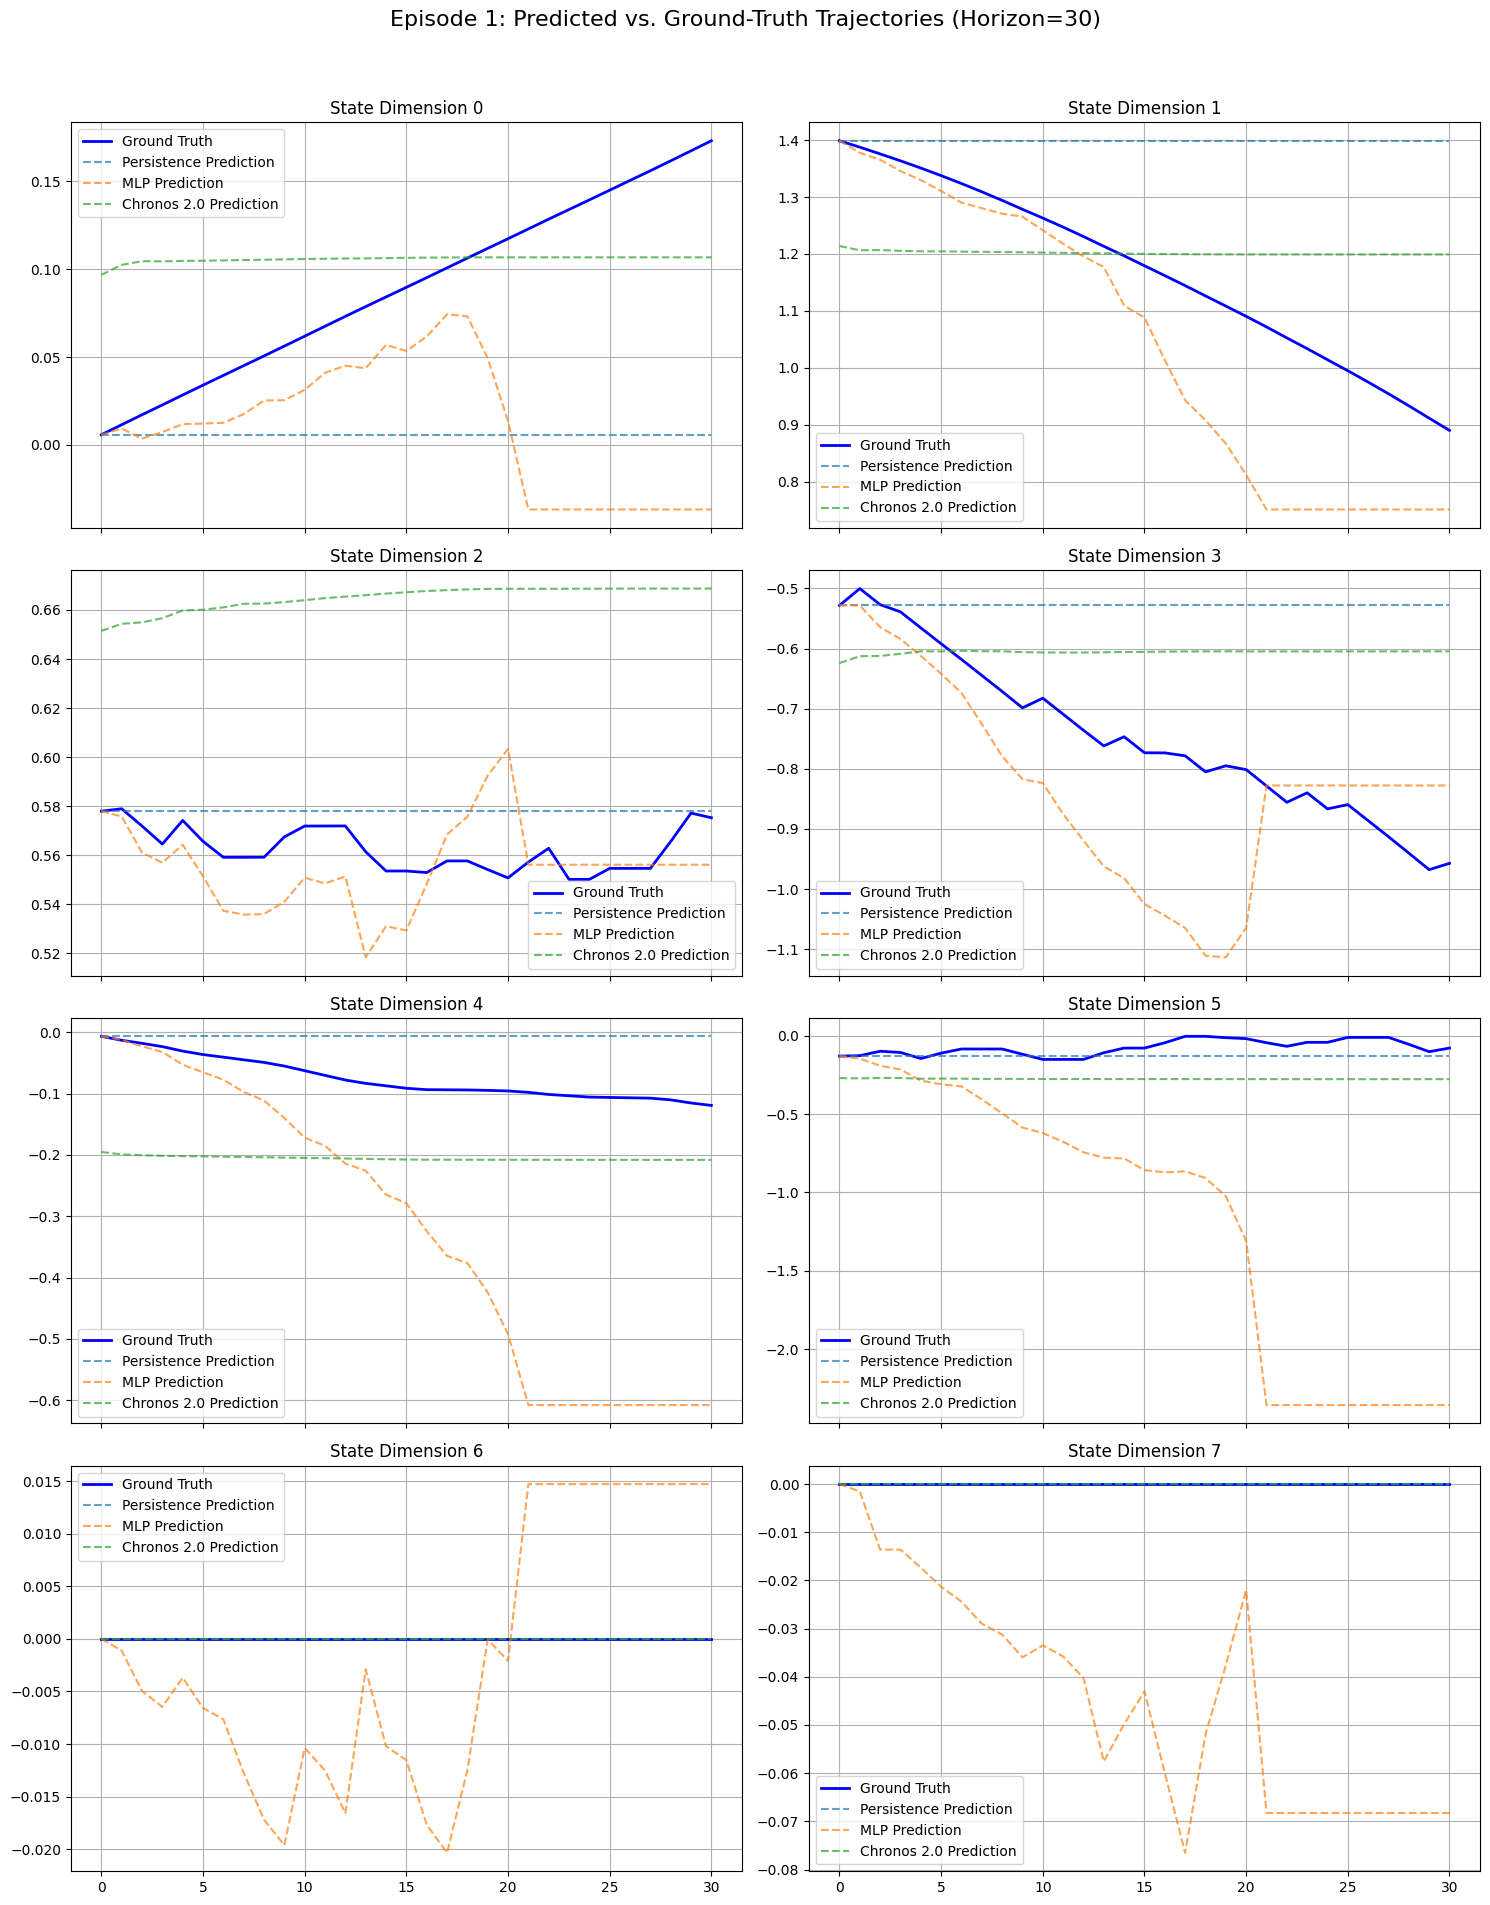


--- Episode 2/10 ---
Persistence Horizon MSE: 0.0126
MLP Horizon MSE: 0.0413
Chronos 2.0 Horizon MSE: 0.0091


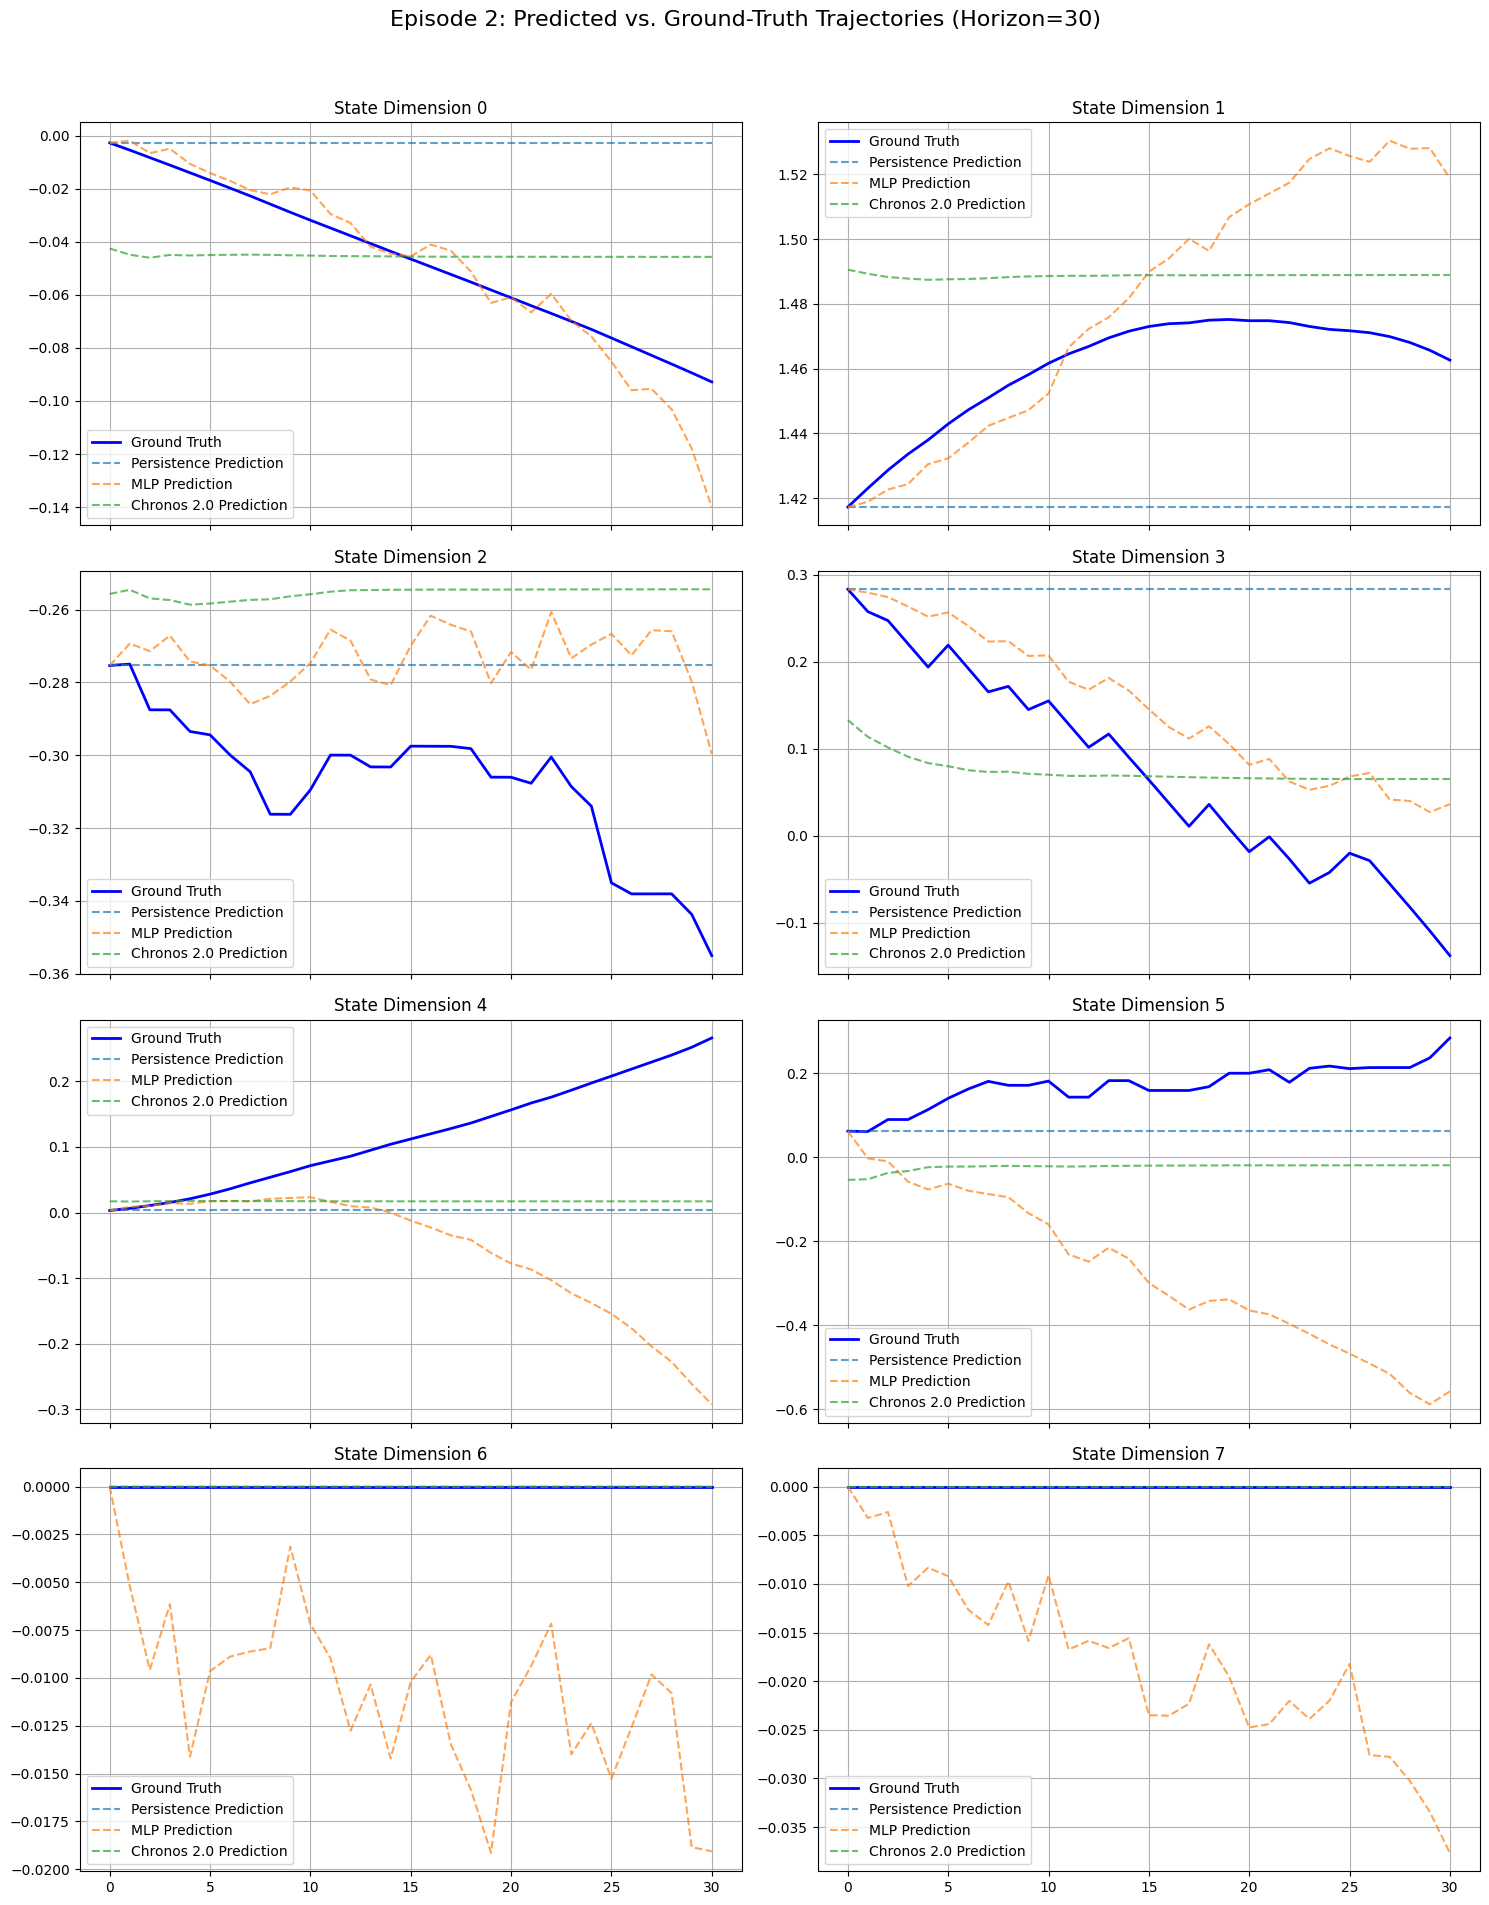


--- Episode 3/10 ---
Persistence Horizon MSE: 0.0065
MLP Horizon MSE: 0.0408
Chronos 2.0 Horizon MSE: 0.0141


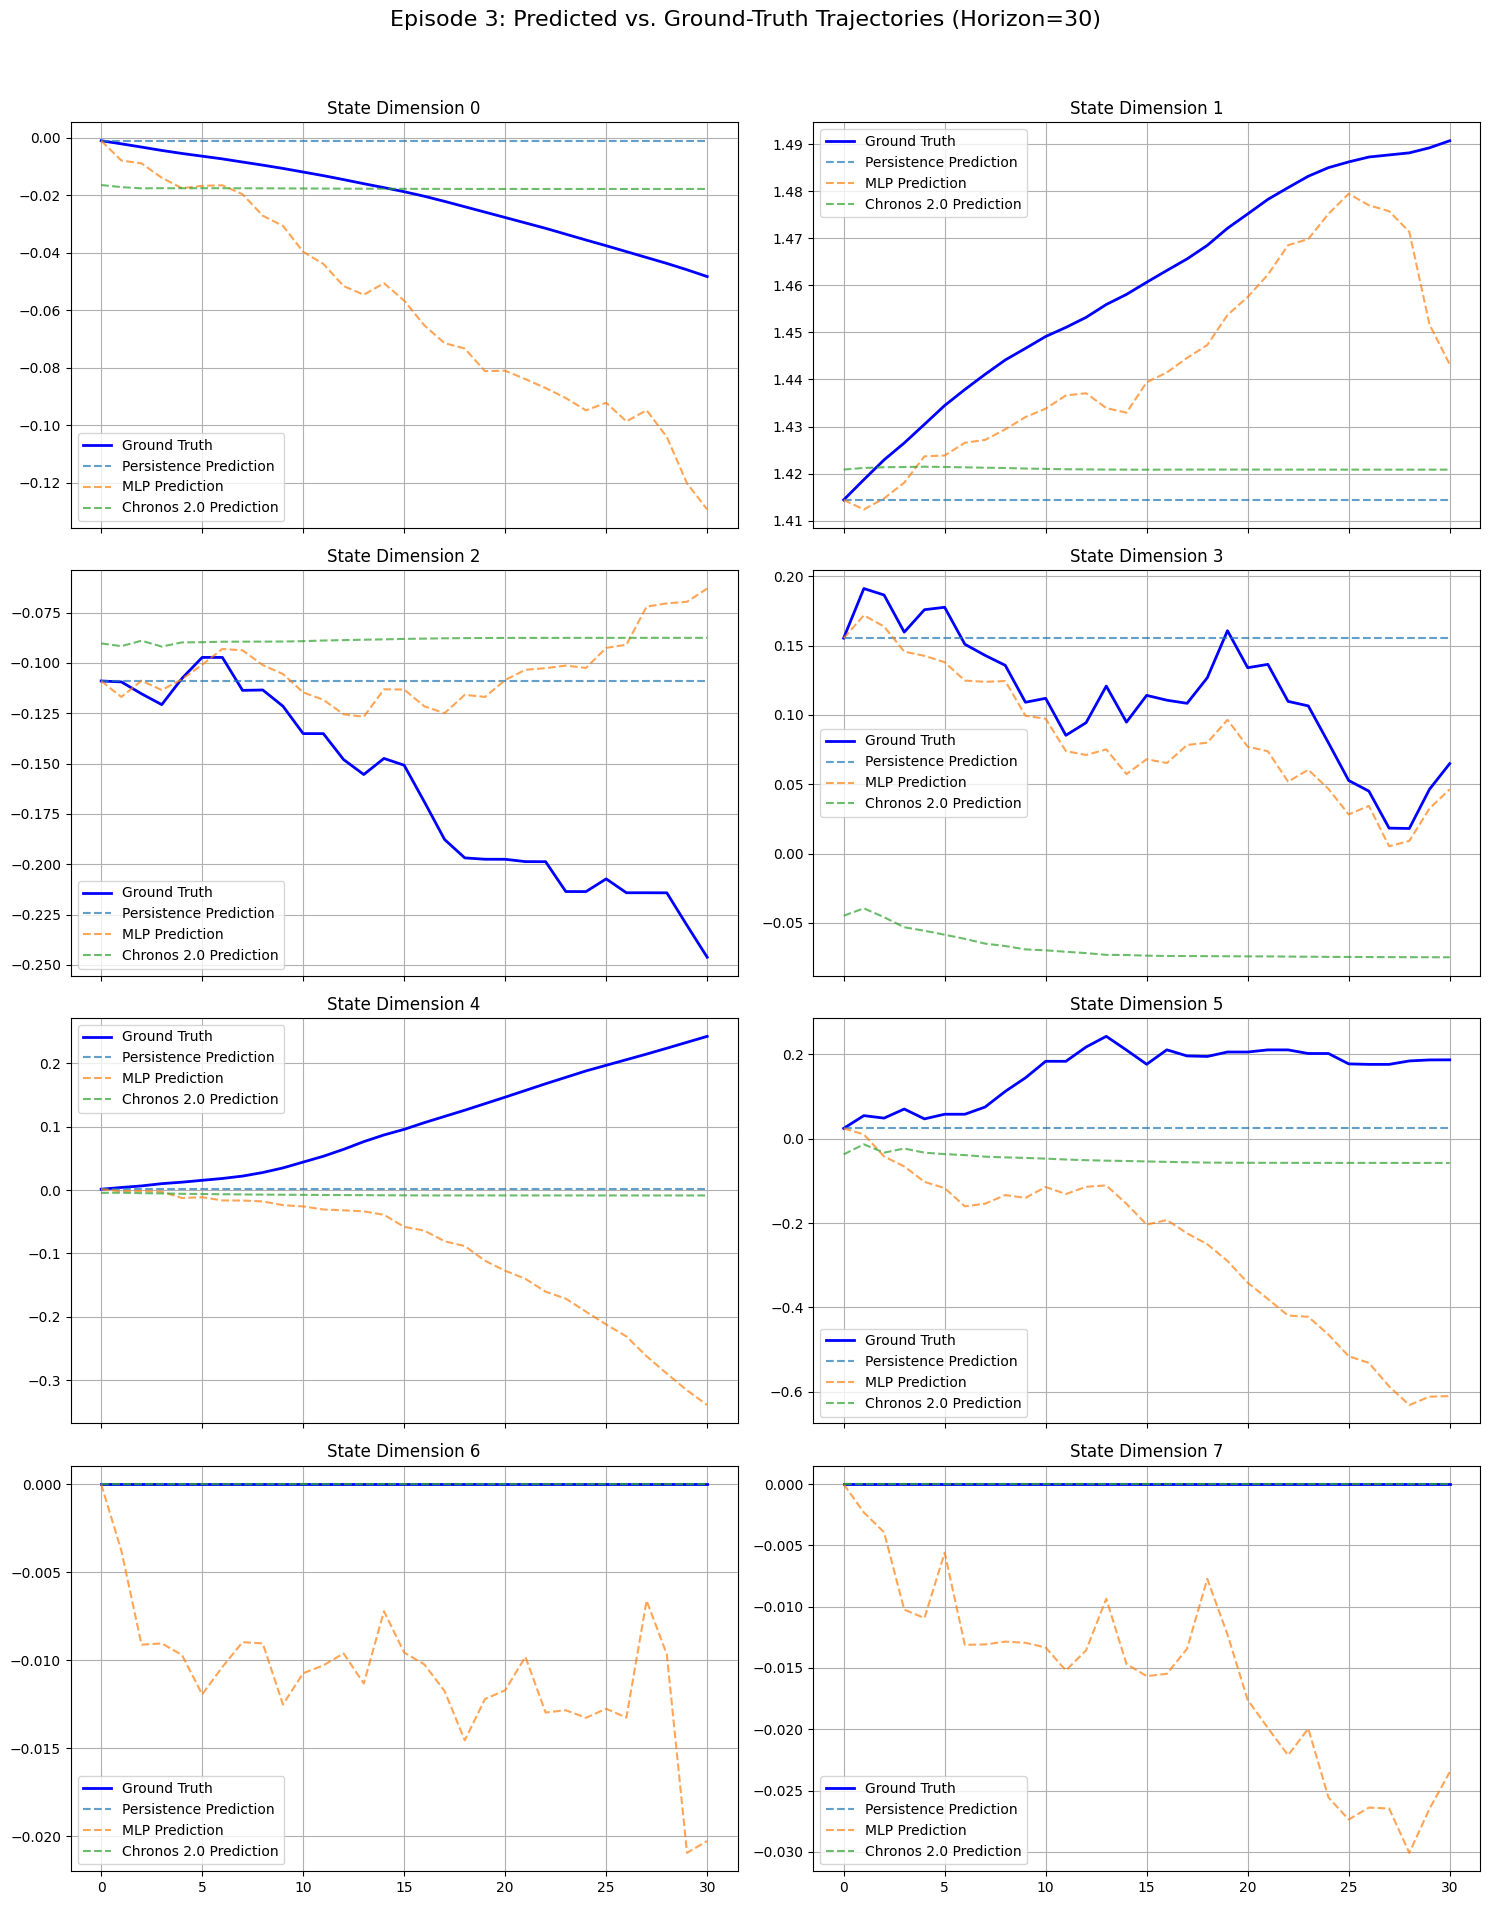


--- Episode 4/10 ---
Persistence Horizon MSE: 0.0043
MLP Horizon MSE: 0.0358
Chronos 2.0 Horizon MSE: 0.0018


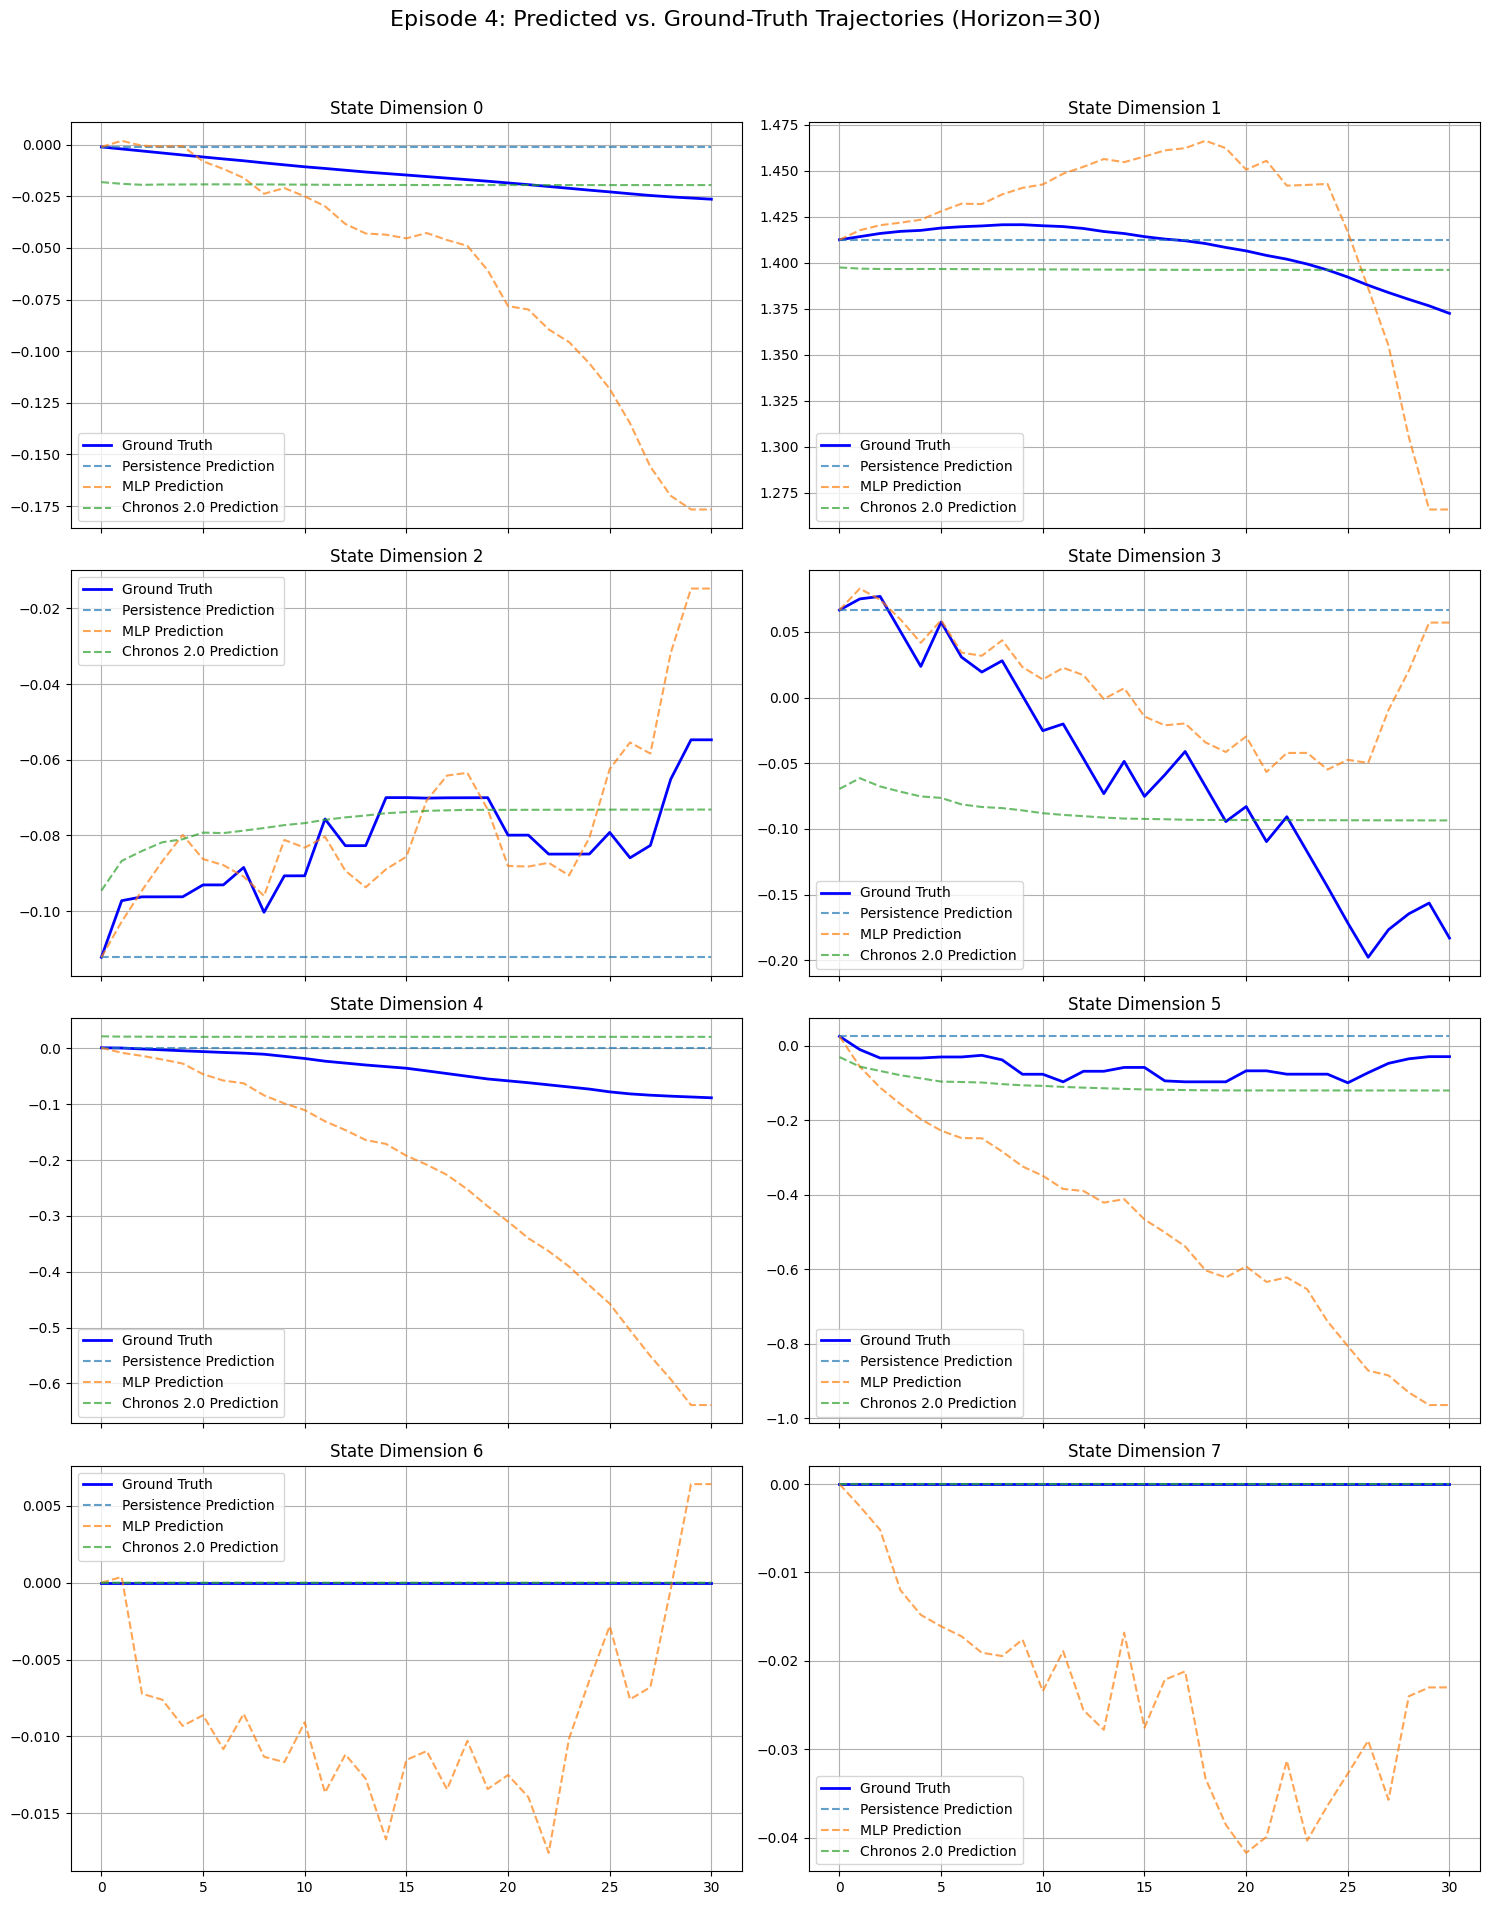


--- Episode 5/10 ---
Persistence Horizon MSE: 0.0066
MLP Horizon MSE: 0.0277
Chronos 2.0 Horizon MSE: 0.0041


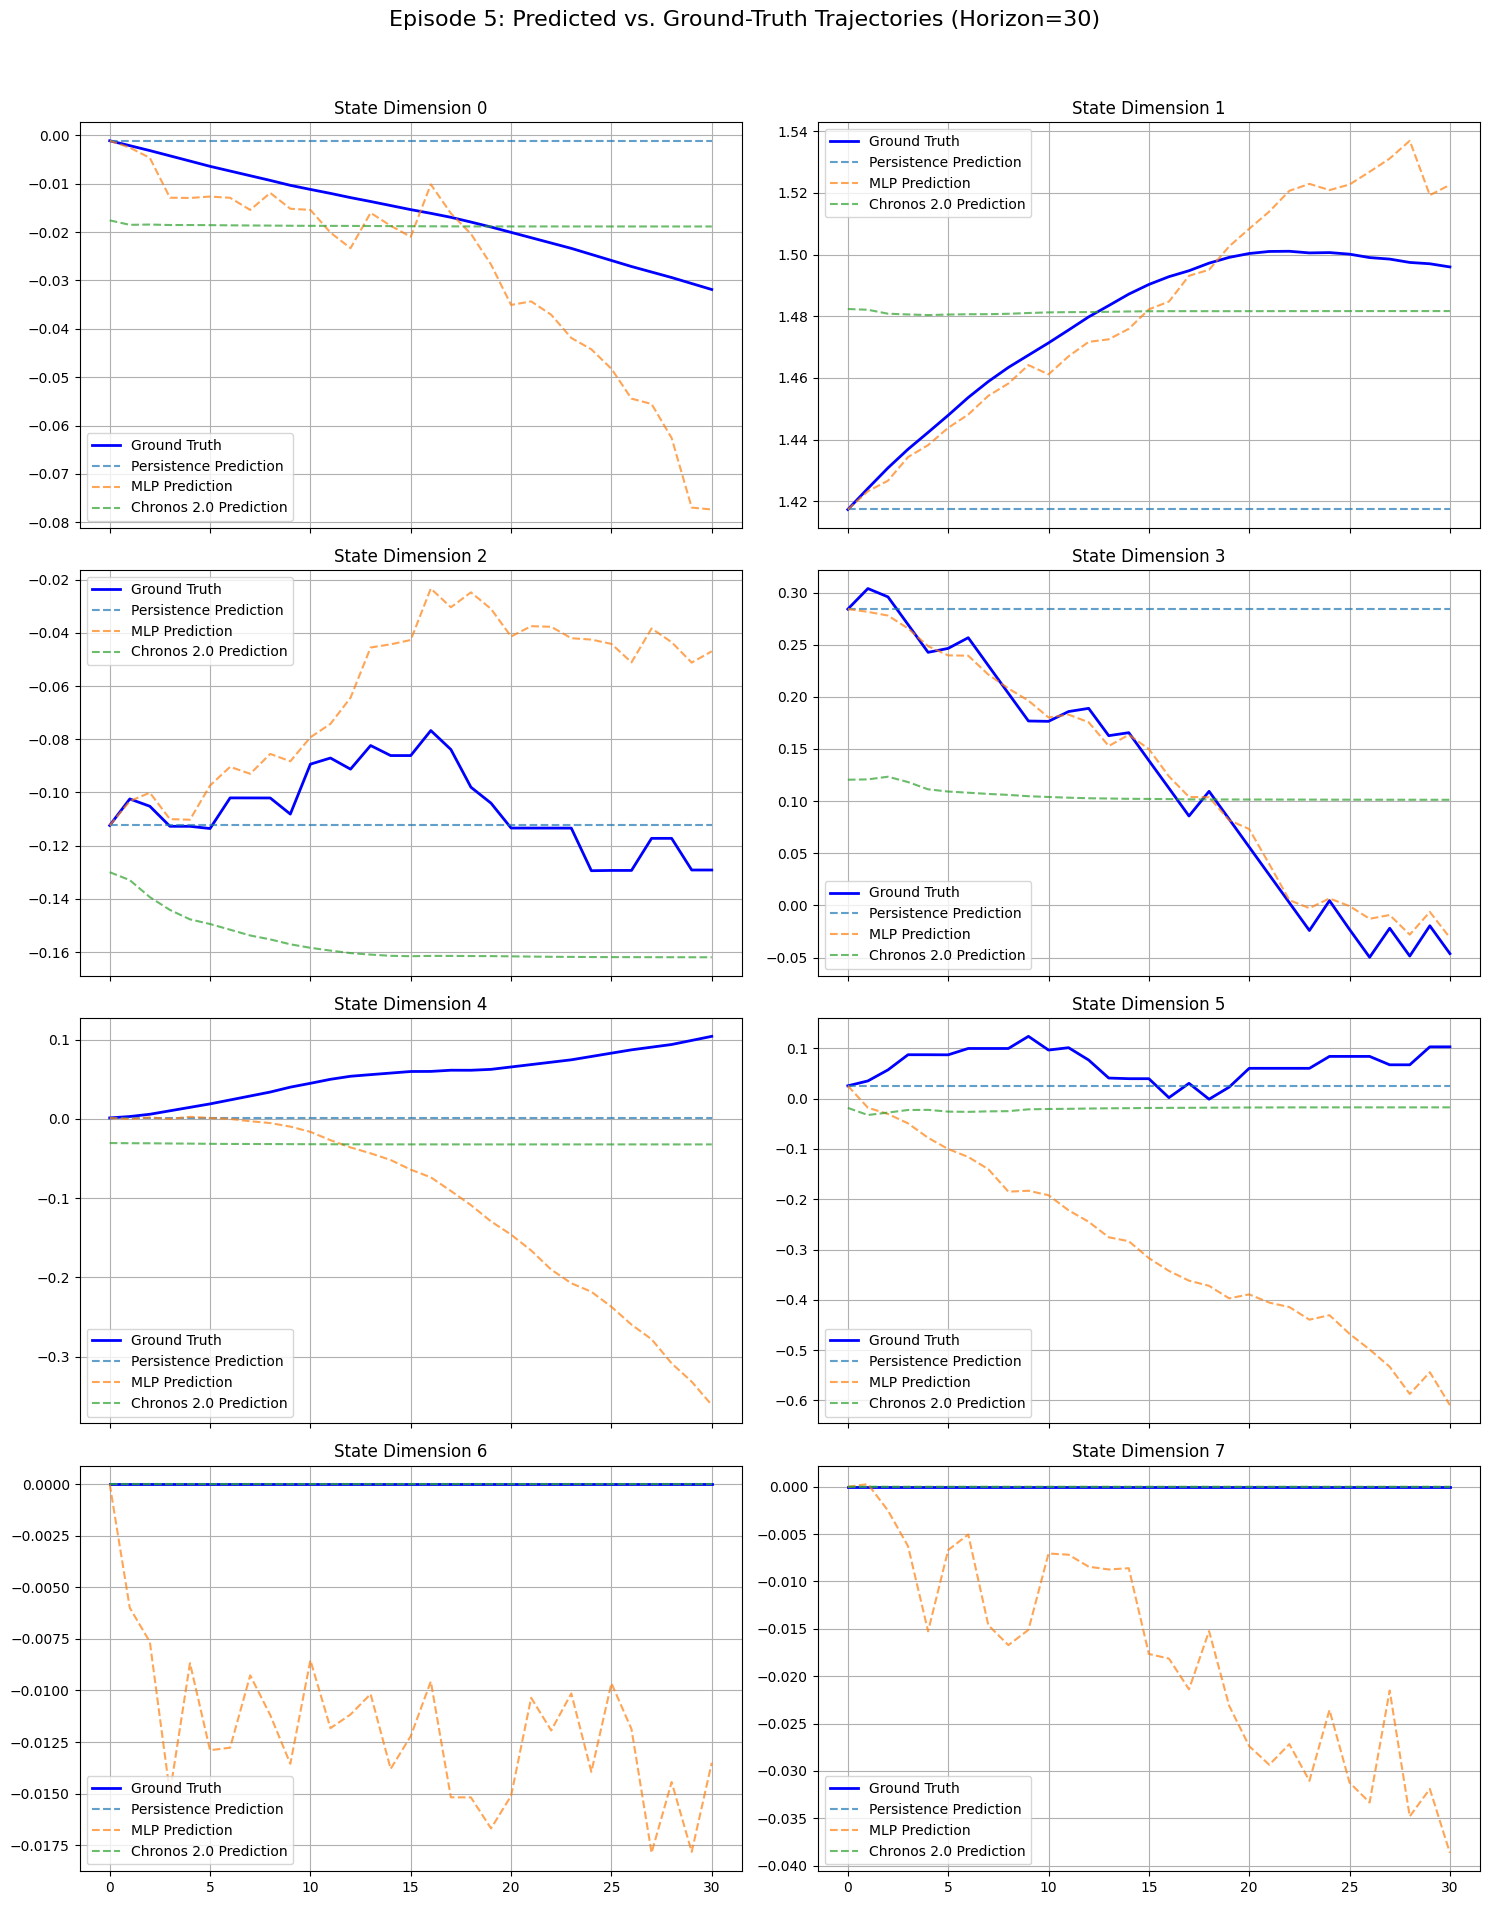


--- Episode 6/10 ---
Persistence Horizon MSE: 0.0092
MLP Horizon MSE: 0.0242
Chronos 2.0 Horizon MSE: 0.0201


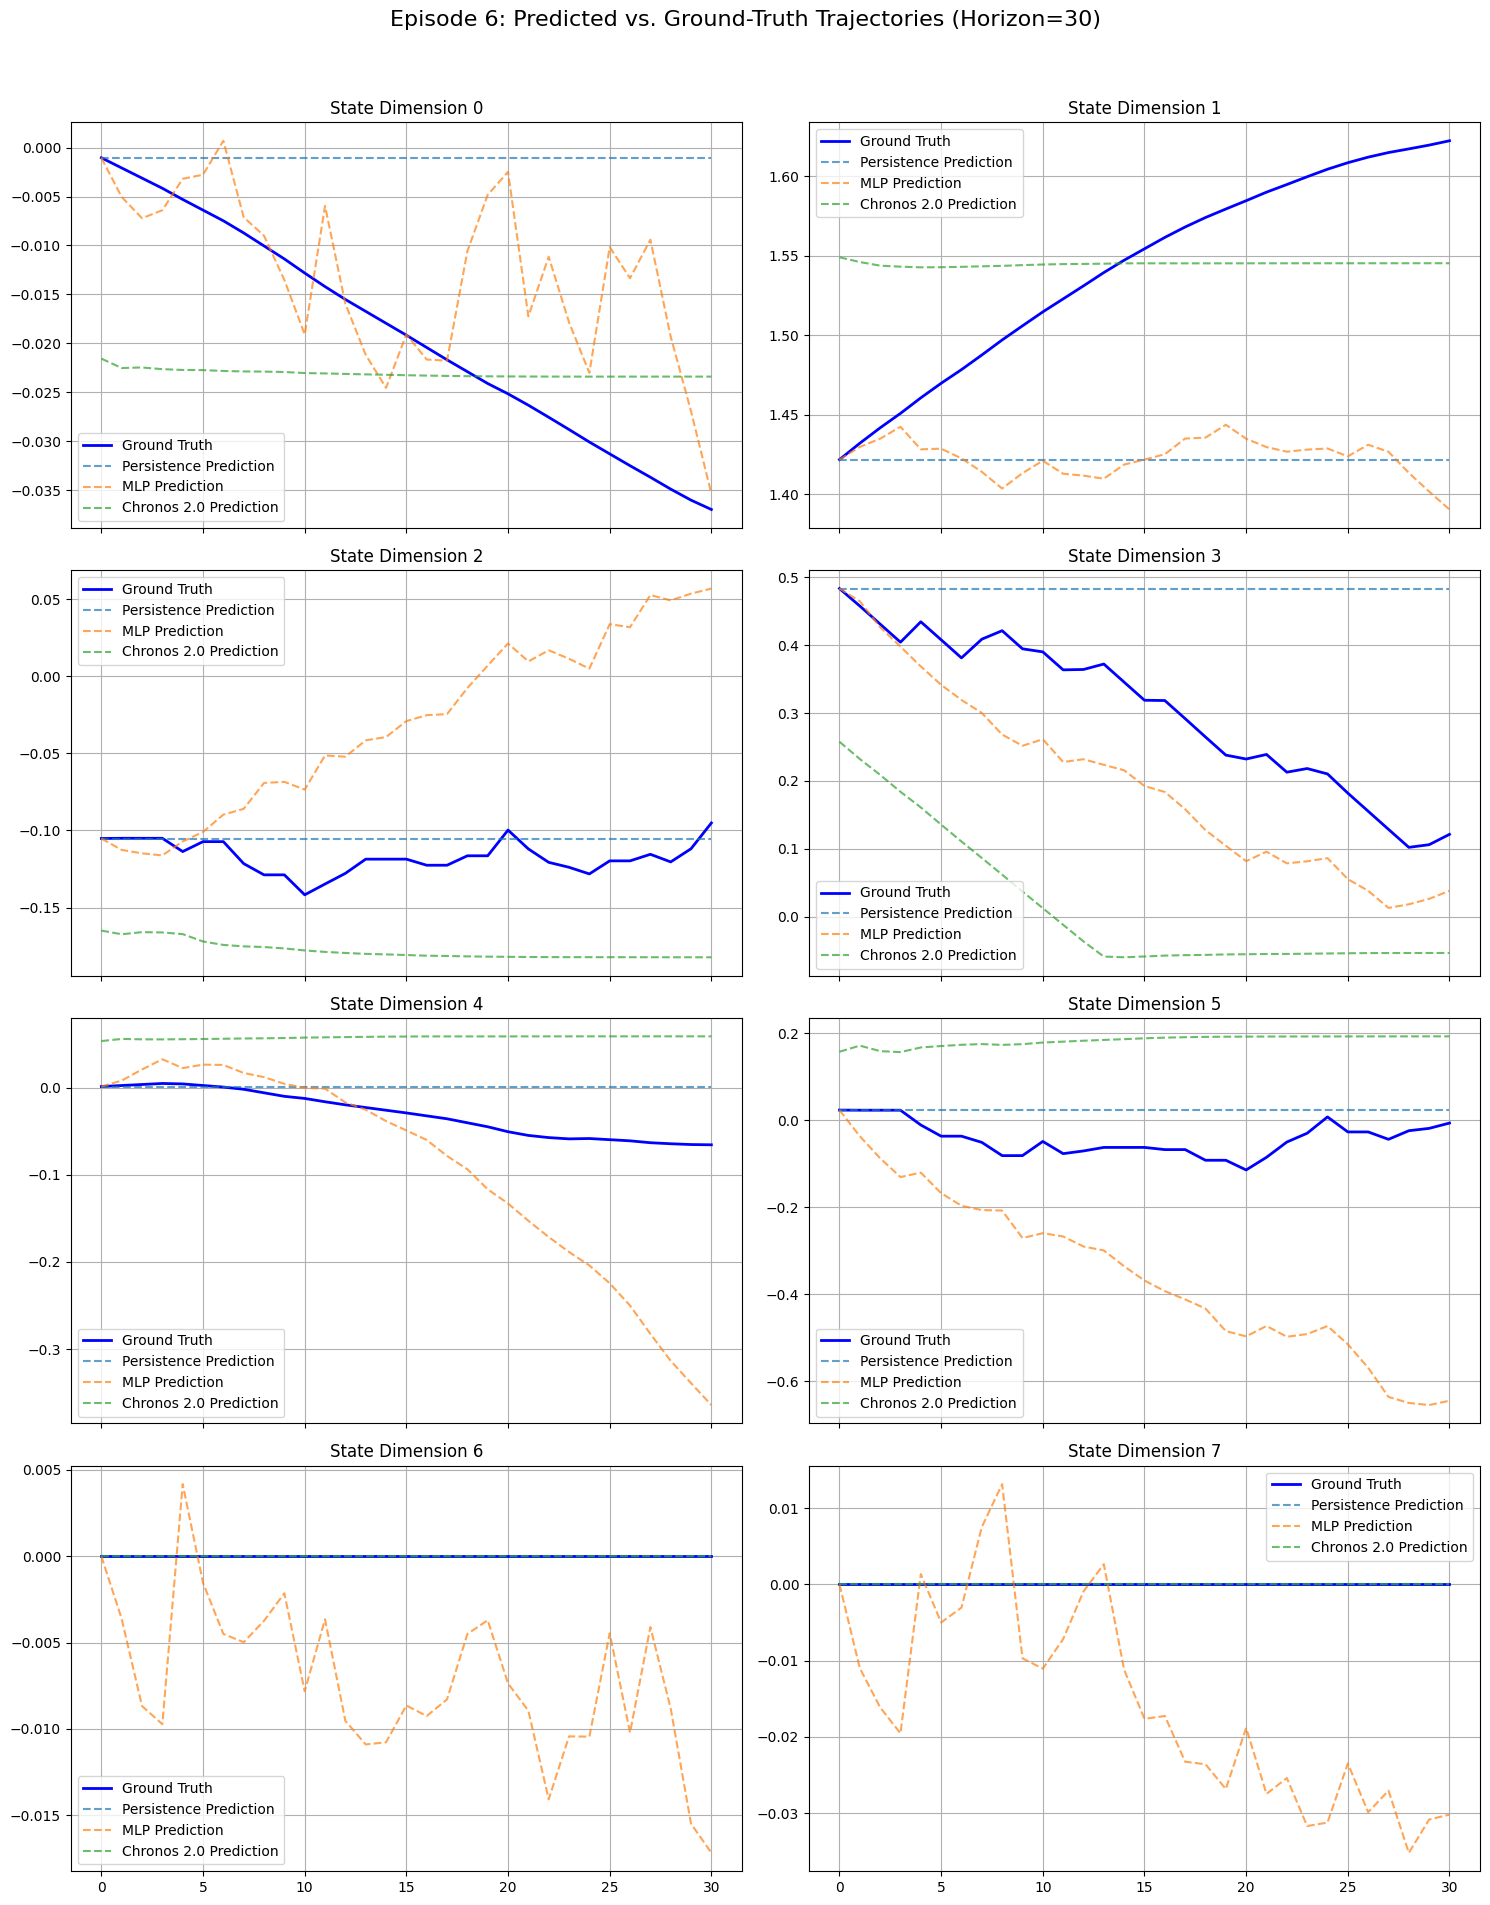


--- Episode 7/10 ---
Persistence Horizon MSE: 0.0160
MLP Horizon MSE: 0.0338
Chronos 2.0 Horizon MSE: 0.0038


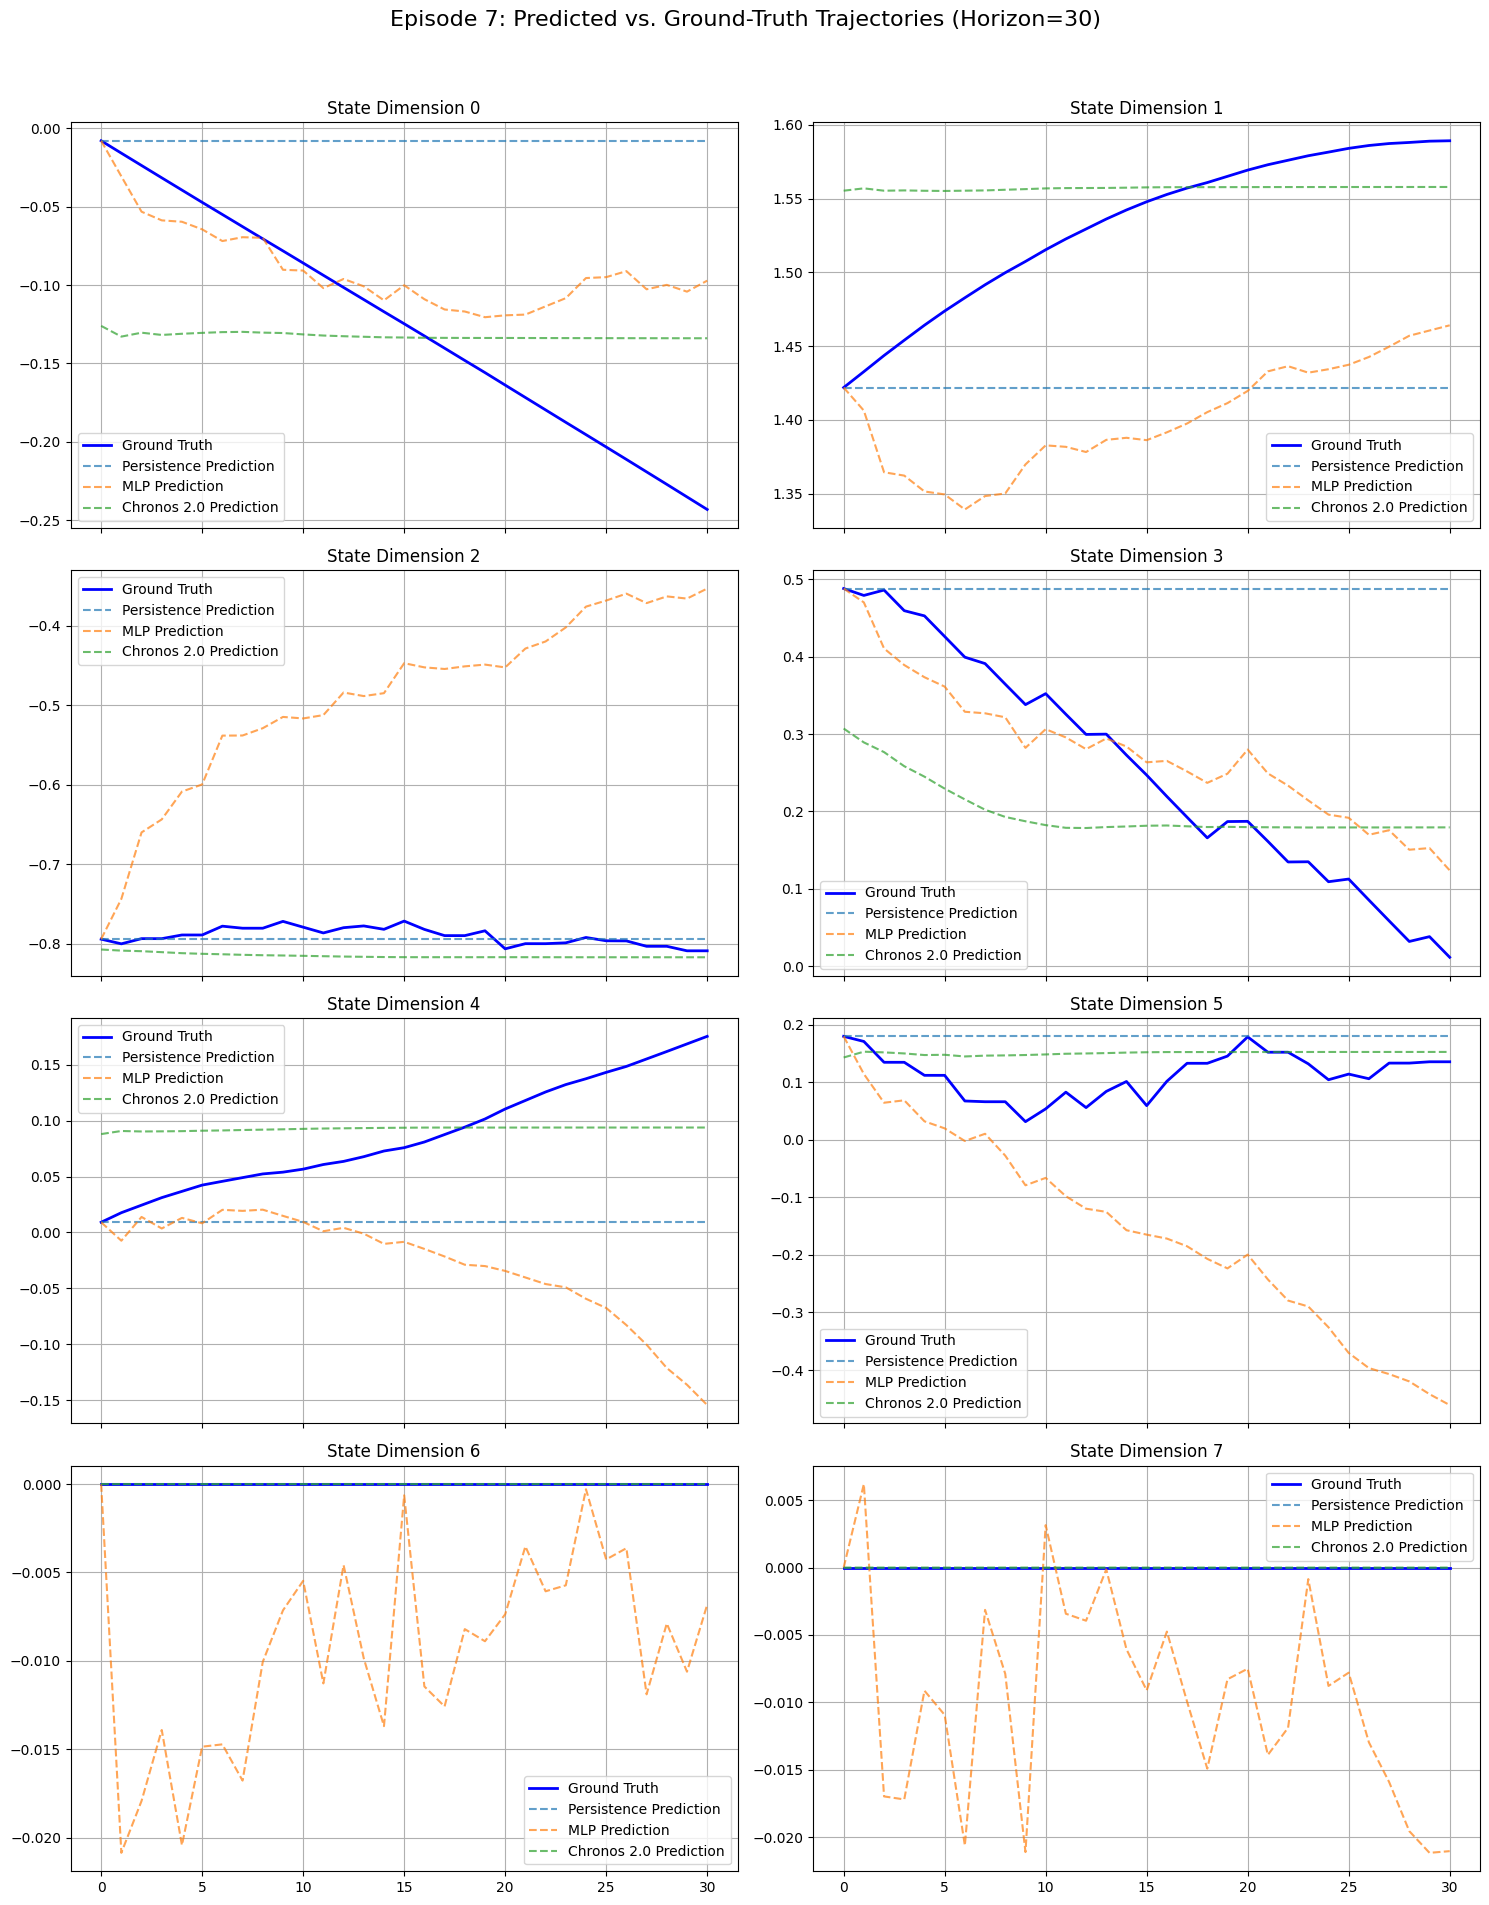


--- Episode 8/10 ---
Persistence Horizon MSE: 0.0069
MLP Horizon MSE: 0.0687
Chronos 2.0 Horizon MSE: 0.0047


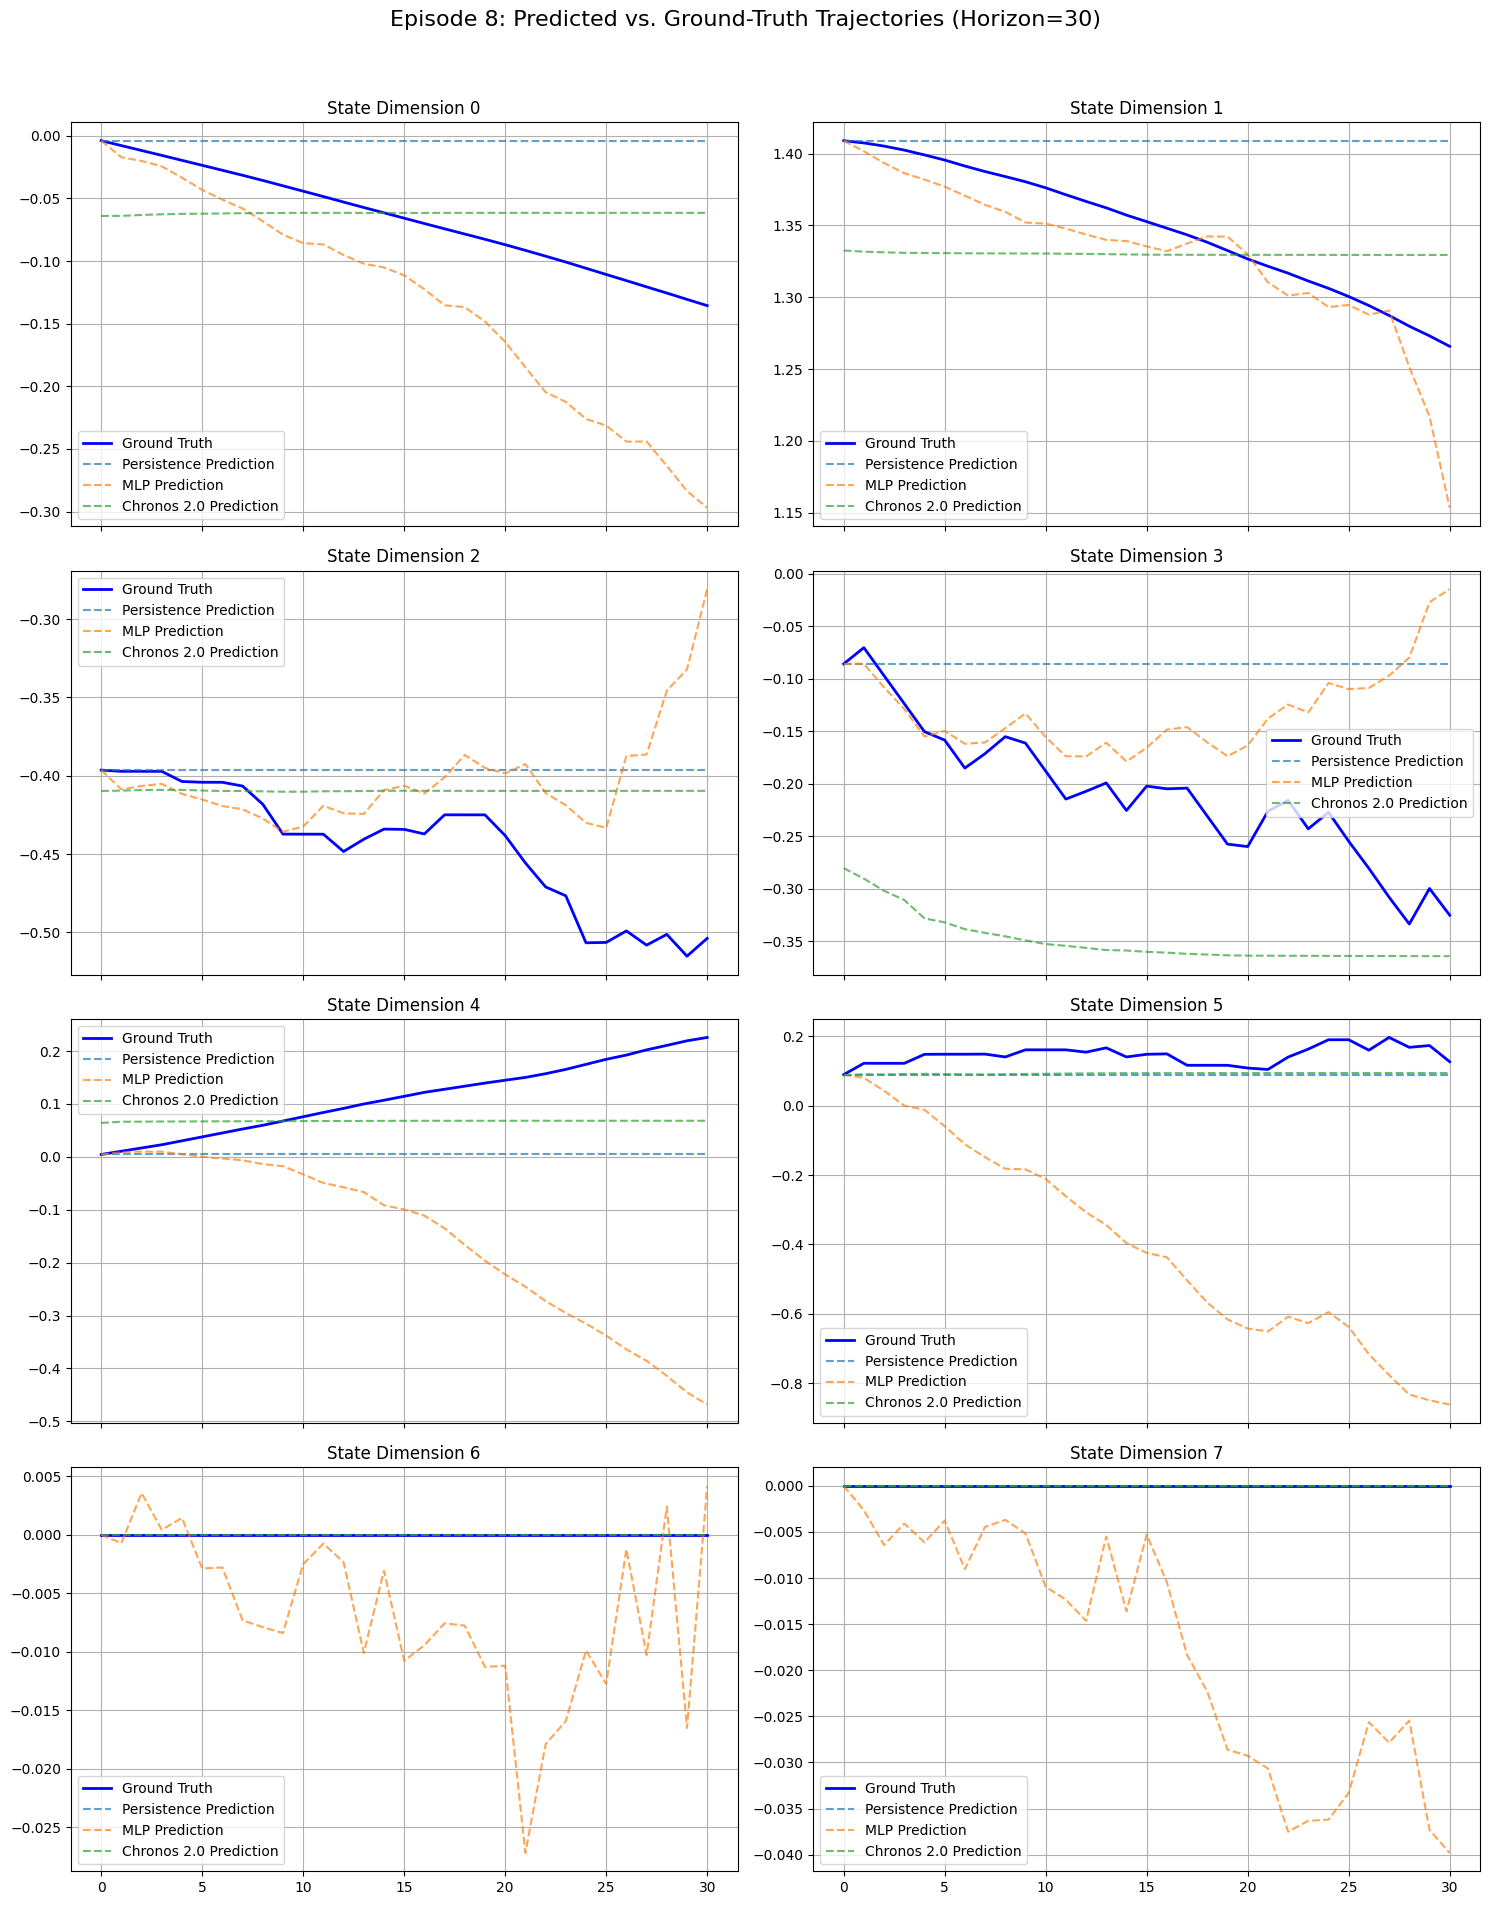


--- Episode 9/10 ---
Persistence Horizon MSE: 0.0123
MLP Horizon MSE: 0.0966
Chronos 2.0 Horizon MSE: 0.0081


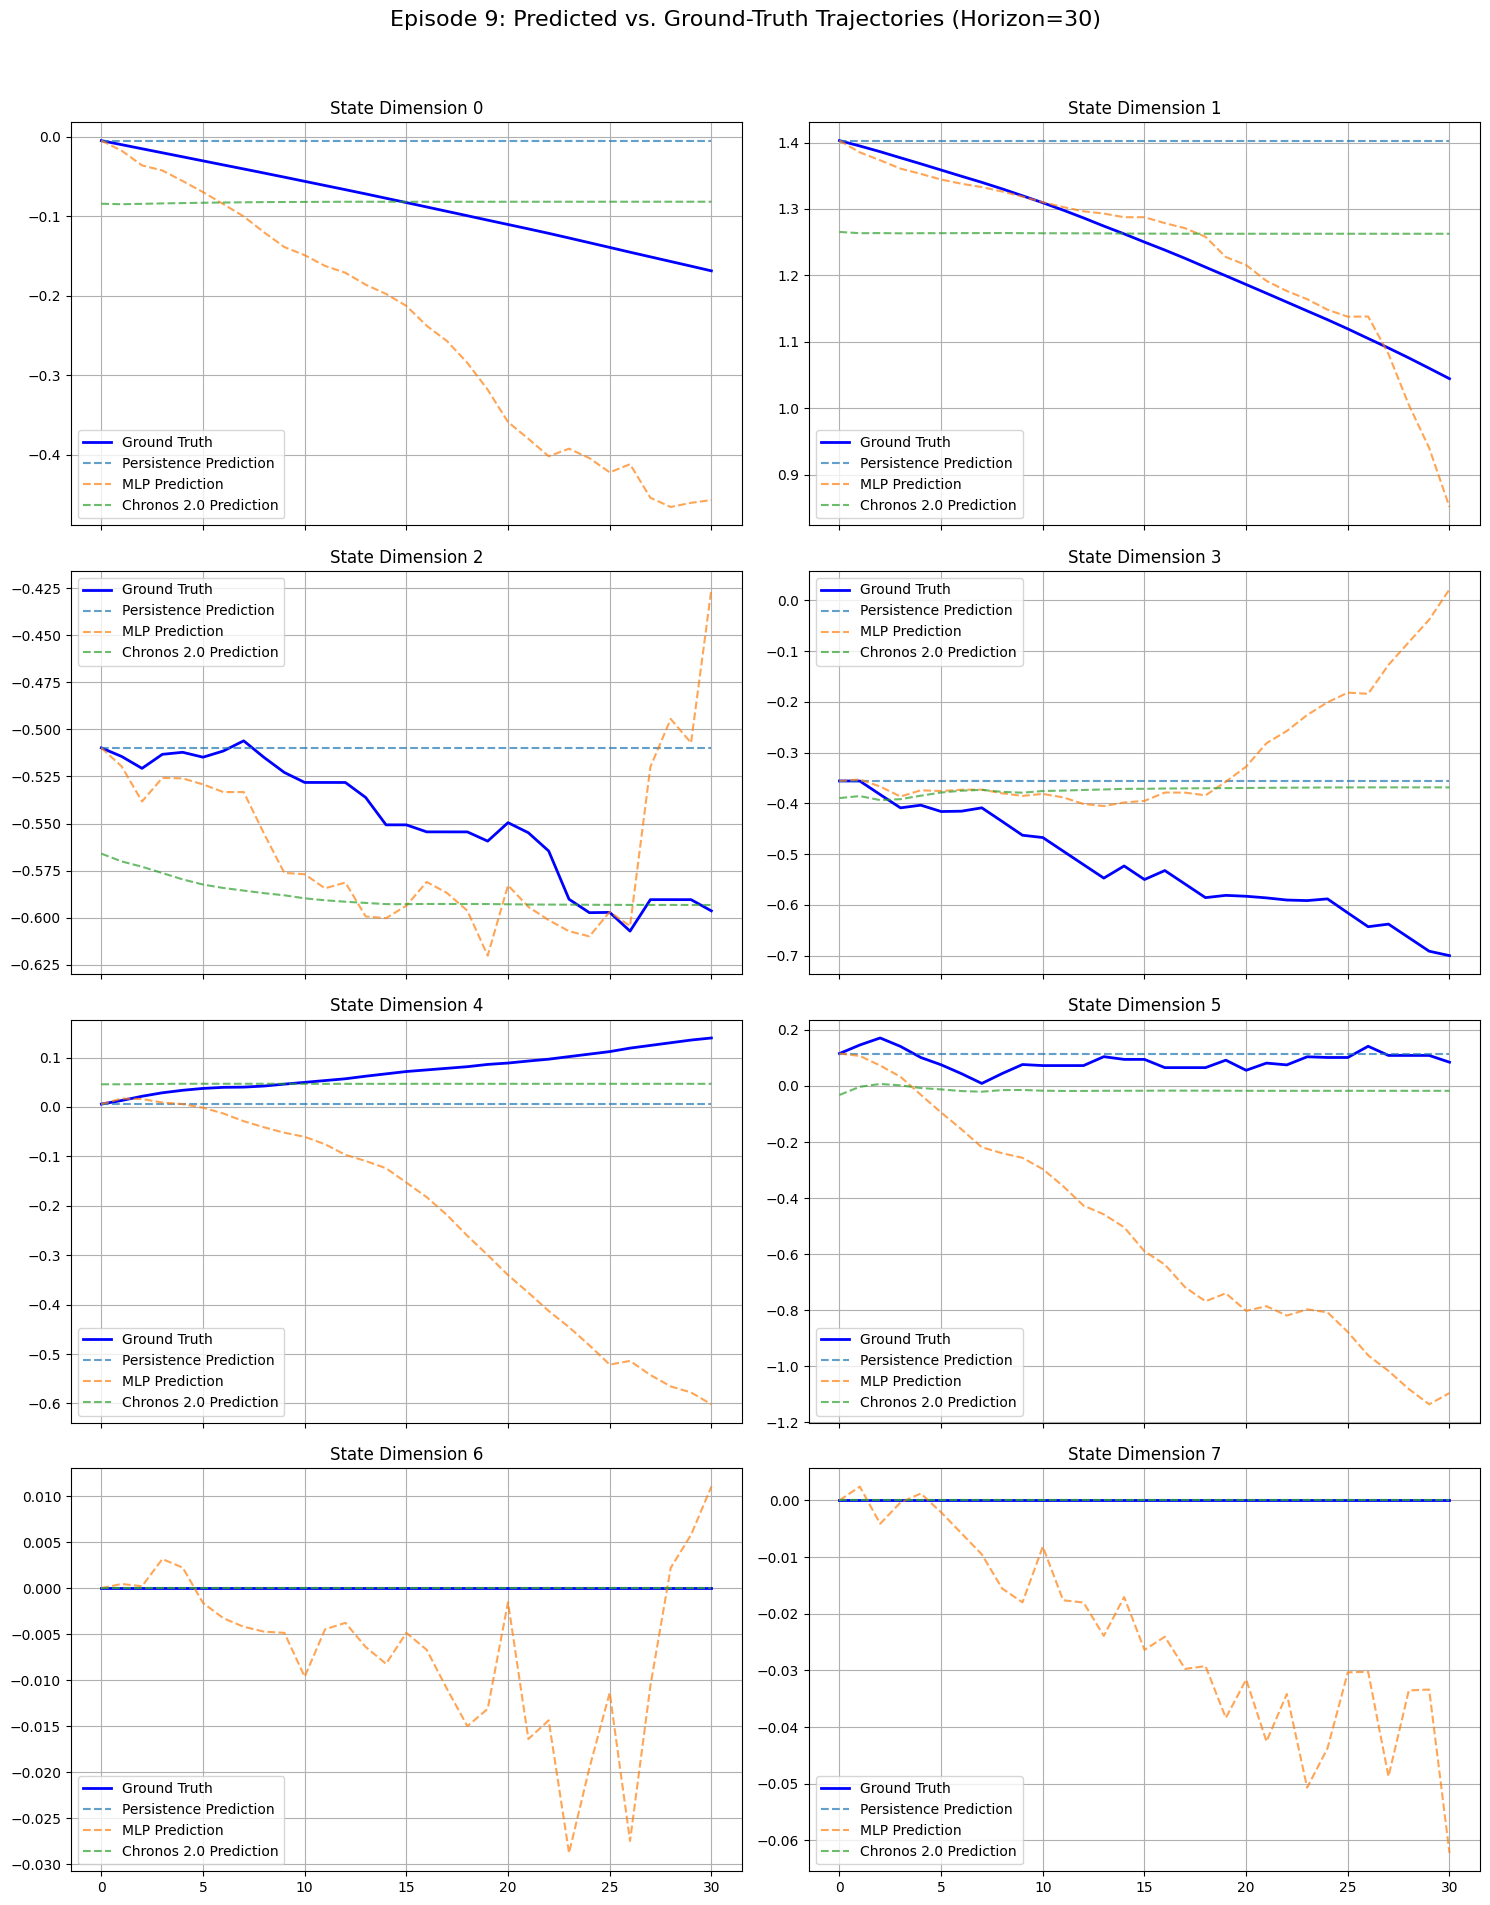


--- Episode 10/10 ---
Persistence Horizon MSE: 0.0161
MLP Horizon MSE: 0.0785
Chronos 2.0 Horizon MSE: 0.0063


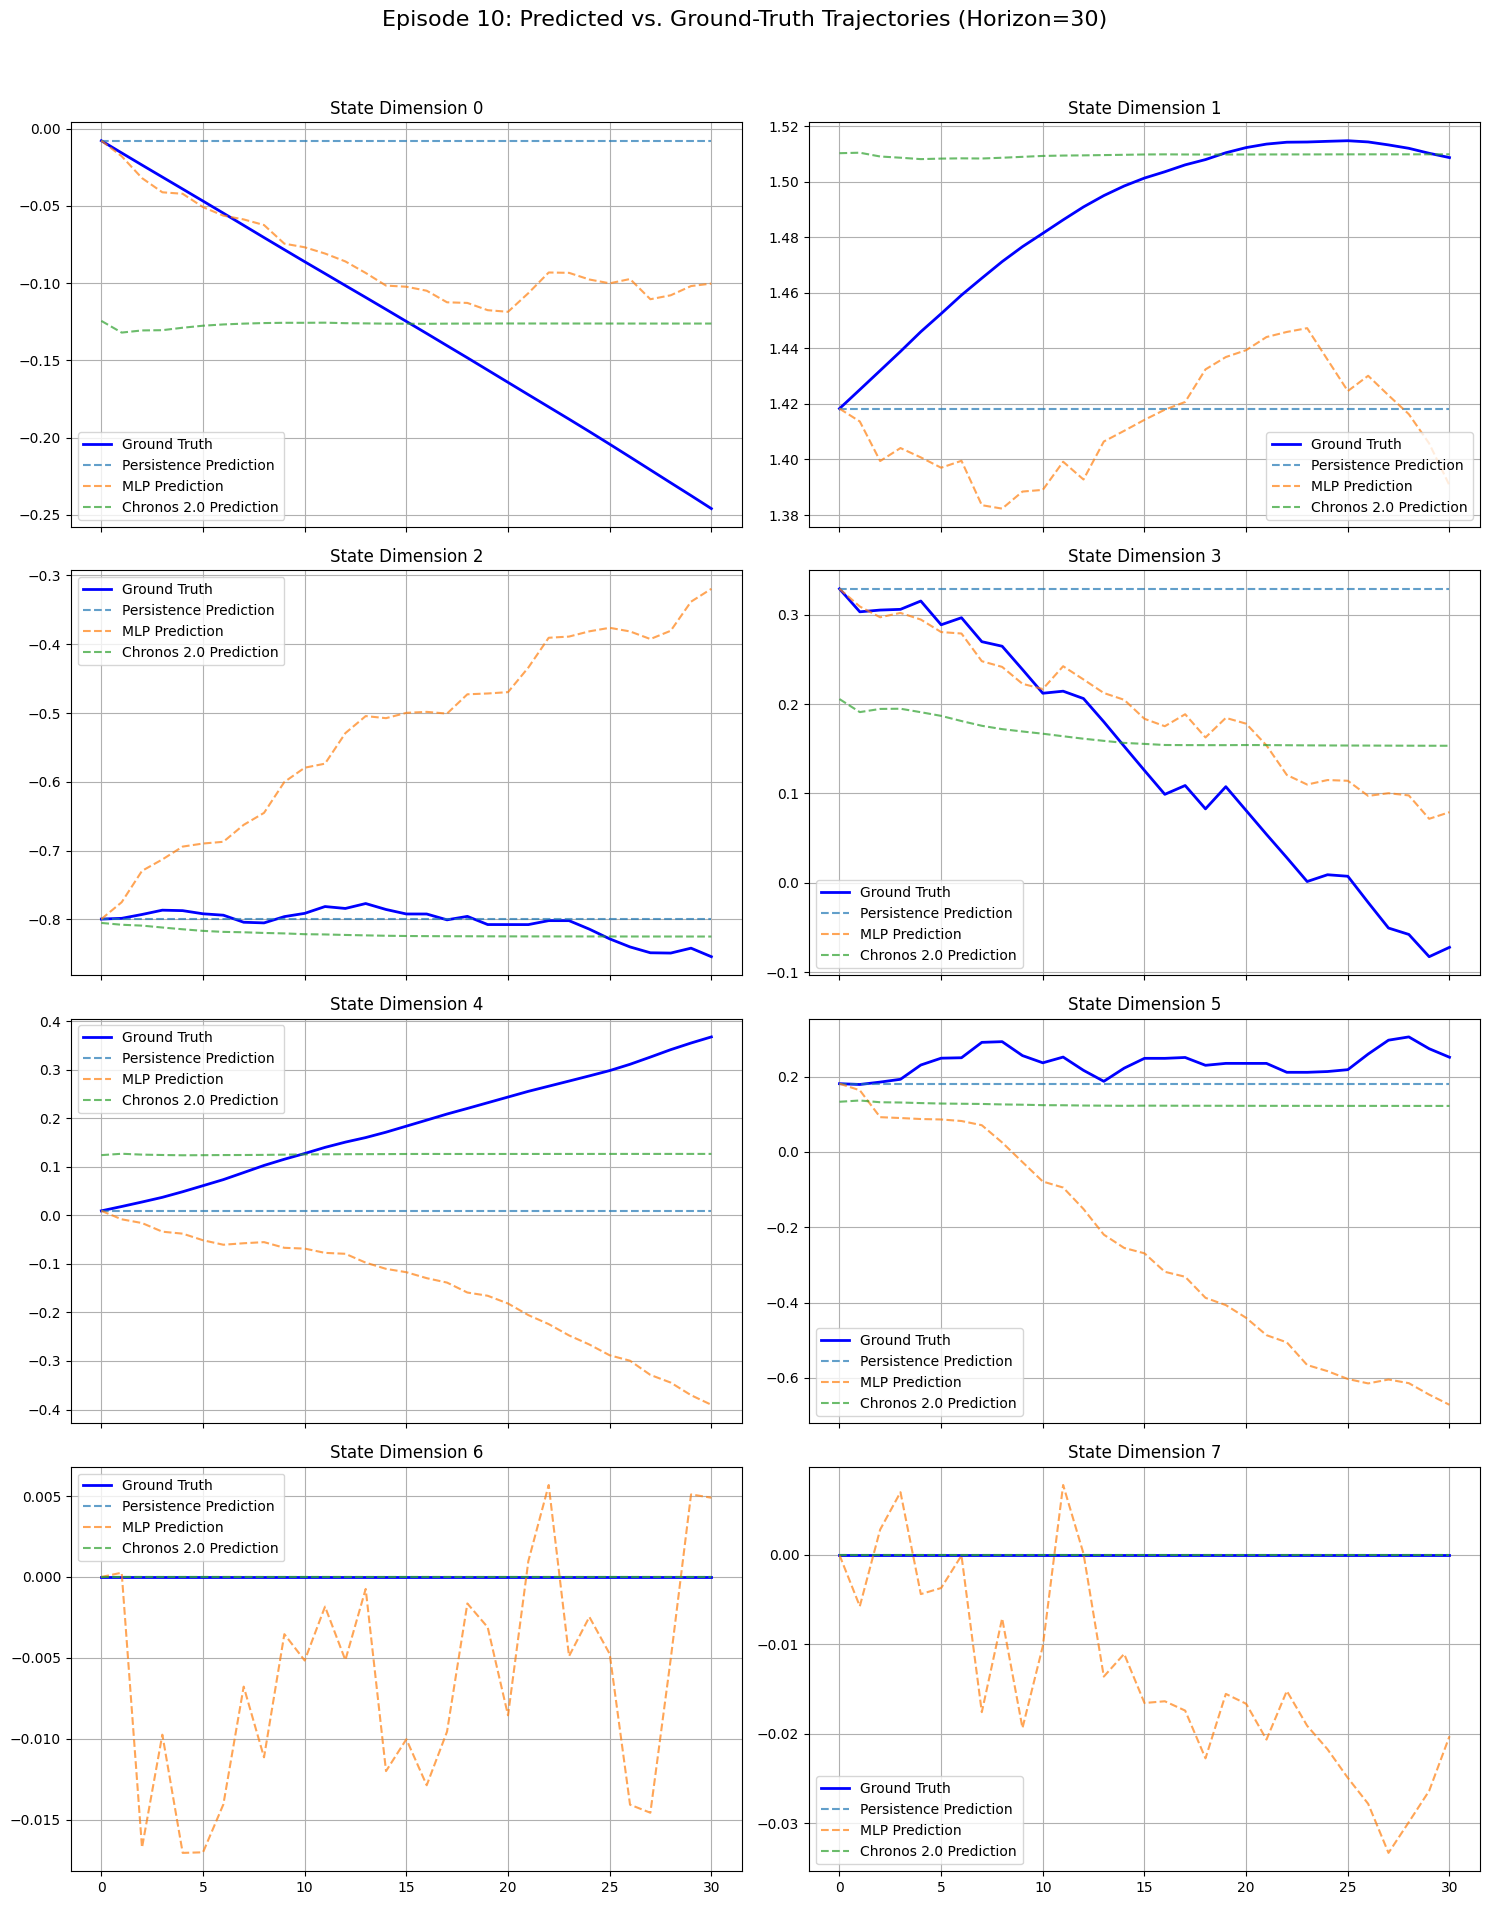


--- Average Horizon MSE Across Episodes ---
Persistence: 0.0112
MLP: 0.0507
Chronos 2.0: 0.0089
World Model Evaluation Complete.

Final Average Horizon MSE Results:
Persistence: 0.0112
MLP: 0.0507
Chronos 2.0: 0.0089


In [22]:
CHRONOS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Chronos 2.0 will run on device: {CHRONOS_DEVICE}")

CONTEXT_LENGTH = 16

average_horizon_mse = evaluate_world_models(
    real_env_name="LunarLanderContinuous-v3",
    mlp_model_instance=mlp_model,
    num_episodes=10,
    horizon=30,     
    chronos_device=CHRONOS_DEVICE,
    context_length=CONTEXT_LENGTH
)
print("\nFinal Average Horizon MSE Results:")
for model_name, mse_value in average_horizon_mse.items():
    print(f"{model_name}: {mse_value:.4f}")